In [1]:
pip install medmnist albumentations timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import torch
import random
import itertools
import time
import seaborn as sns


# Dataset
from medmnist import BloodMNIST
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Train test split
from sklearn.model_selection import train_test_split

# Model & Hyperparameters
import torch.nn as nn
import torch.nn.functional as F
import timm
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler

# Evaluation Metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [3]:
torch.cuda.is_available()

True

In [4]:
CLASS_NAMES = [
    'Basophil', 'Eosinophil', 'Erythroblast', 'Immature Granulocyte',
    'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet'
]
NUM_CLASSES = 8

## Load BloodMNIST at 128x128 resolution

In [5]:
train_data = BloodMNIST(split = 'train', download = True, size = 128)
val_data = BloodMNIST(split = 'val', download = True, size = 128)
test_data = BloodMNIST(split = 'test', download = True, size = 128)

100%|██████████| 569M/569M [00:45<00:00, 12.6MB/s] 


In [6]:
print("Train dataset size: ", len(train_data))
print("Validation dataset size: ", len(val_data))
print("Test dataset size: ", len(test_data))

Train dataset size:  11959
Validation dataset size:  1712
Test dataset size:  3421


# Data Exploration

## Single Image Array & Corresponding Label

In [7]:
sample_img, sample_label = train_data[0]
print("=== Single Sample ===")
print(f"Type : {type(sample_img)}")
print(f"Mode : {sample_img.mode}")
print(f"Size : {sample_img.size}")

=== Single Sample ===
Type : <class 'PIL.Image.Image'>
Mode : RGB
Size : (128, 128)


In [8]:
sample_arr = np.array(sample_img)
# print(sample_arr)
print(f"As numpy array: {sample_arr.shape}")
print(f"Dtype: {sample_arr.dtype}")
print(f"Pixel range: [{sample_arr.min()}, {sample_arr.max()}]")
print(f"Label : {sample_label} --> {CLASS_NAMES[int(sample_label)]}")

As numpy array: (128, 128, 3)
Dtype: uint8
Pixel range: [16, 255]
Label : [7] --> Platelet


/tmp/ipykernel_57/1466784828.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Label : {sample_label} --> {CLASS_NAMES[int(sample_label)]}")


## Per Channel Statistics (Mean, Min, Max)

In [9]:
# --- Per-channel stats on a single image ---
print("\n=== Per-Channel Stats (single image) ===")
for i, ch in enumerate(['R', 'G', 'B']):
    ch_data = sample_arr[:, :, i]
    print(f"  {ch} — mean: {ch_data.mean():.2f}, std: {ch_data.std():.2f}, "
          f"min: {ch_data.min()}, max: {ch_data.max()}")



=== Per-Channel Stats (single image) ===
  R — mean: 230.46, std: 33.85, min: 74, max: 255
  G — mean: 198.78, std: 43.60, min: 16, max: 234
  B — mean: 186.16, std: 16.77, min: 126, max: 208


In [10]:
all_indices = np.arange(len(train_data))
all_labels  = np.array([int(label) for _, label in train_data])

/tmp/ipykernel_57/1902015986.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  all_labels  = np.array([int(label) for _, label in train_data])


In [11]:
all_indices

array([    0,     1,     2, ..., 11956, 11957, 11958])

In [12]:
all_labels

array([7, 3, 6, ..., 1, 6, 4])

## Label Distribution in the BloodMNIST Dataset

In [13]:
# --- Dataset-level label distribution ---
print("\n=== Label Distribution (train set) ===")
unique, counts = np.unique(all_labels, return_counts=True)
total = len(all_labels)
for cls, cnt in zip(unique, counts):
    bar = '█' * (cnt // 50)
    print(f"  {CLASS_NAMES[cls]:<28} : {cnt:>5} ({cnt/total*100:.1f}%)  {bar}")



=== Label Distribution (train set) ===
  Basophil                     :   852 (7.1%)  █████████████████
  Eosinophil                   :  2181 (18.2%)  ███████████████████████████████████████████
  Erythroblast                 :  1085 (9.1%)  █████████████████████
  Immature Granulocyte         :  2026 (16.9%)  ████████████████████████████████████████
  Lymphocyte                   :   849 (7.1%)  ████████████████
  Monocyte                     :   993 (8.3%)  ███████████████████
  Neutrophil                   :  2330 (19.5%)  ██████████████████████████████████████████████
  Platelet                     :  1643 (13.7%)  ████████████████████████████████


In [14]:
# --- Class imbalance ratio ---
print(f"\n  Most frequent class  : {CLASS_NAMES[counts.argmax()]} ({counts.max()})")
print(f"  Least frequent class : {CLASS_NAMES[counts.argmin()]} ({counts.min()})")
print(f"  Imbalance ratio      : {counts.max() / counts.min():.2f}x")


  Most frequent class  : Neutrophil (2330)
  Least frequent class : Lymphocyte (849)
  Imbalance ratio      : 2.74x


In [15]:
counts

array([ 852, 2181, 1085, 2026,  849,  993, 2330, 1643])

In [16]:
# --- Pixel intensity distribution per channel across full train set ---
# Sample 500 images for speed
sample_size = 500
sample_idx  = np.random.choice(len(train_data), sample_size, replace=False)
sample_imgs = np.stack([np.array(train_data[i][0]) for i in sample_idx], axis=0) / 255.0

print("\n=== Per-Channel Stats (500-image sample) ===")
for i, ch in enumerate(['R', 'G', 'B']):
    ch_data = sample_imgs[:, :, :, i]
    print(f"  {ch} — mean: {ch_data.mean():.4f}, std: {ch_data.std():.4f}, "
          f"min: {ch_data.min():.4f}, max: {ch_data.max():.4f}")


=== Per-Channel Stats (500-image sample) ===
  R — mean: 0.7950, std: 0.2268, min: 0.0510, max: 1.0000
  G — mean: 0.6594, std: 0.2605, min: 0.0157, max: 0.9922
  B — mean: 0.6982, std: 0.0972, min: 0.3804, max: 1.0000


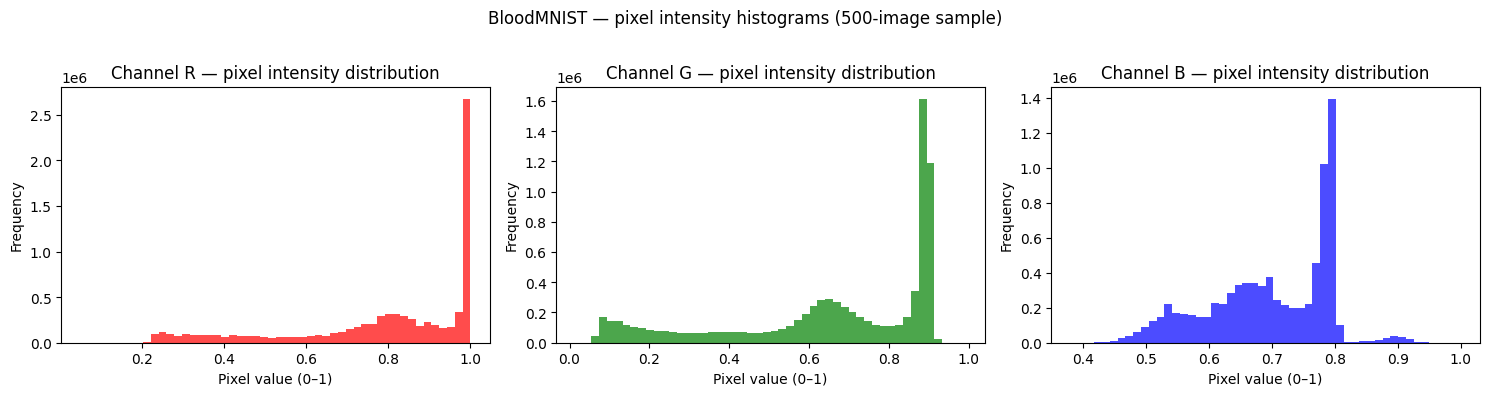


=== Matrix View: R channel of sample image (top-left 8×8 patch) ===
[[253 254 255 254 253 253 253 253]
 [253 254 255 254 253 253 253 253]
 [253 254 255 254 253 253 253 253]
 [253 254 255 254 253 253 253 253]
 [254 254 254 254 254 253 253 253]
 [254 254 254 254 254 253 253 253]
 [254 254 254 254 254 252 252 252]
 [254 254 254 254 254 253 253 253]]


In [17]:
# --- Visualize pixel intensity histograms per channel ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'green', 'blue']
for i, (ch, color) in enumerate(zip(['R', 'G', 'B'], colors)):
    axes[i].hist(sample_imgs[:, :, :, i].ravel(), bins=50, color=color, alpha=0.7)
    axes[i].set_title(f'Channel {ch} — pixel intensity distribution')
    axes[i].set_xlabel('Pixel value (0–1)')
    axes[i].set_ylabel('Frequency')
plt.suptitle('BloodMNIST — pixel intensity histograms (500-image sample)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Matrix view: print one channel as a small grid ---
print("\n=== Matrix View: R channel of sample image (top-left 8×8 patch) ===")
print(sample_arr[:8, :8, 0])  # raw uint8 values

In [18]:
print(sample_img)
print(sample_label)

<PIL.Image.Image image mode=RGB size=128x128 at 0x7EA117F03920>
[7]


## Normalize images for smooth gradient flow

In [19]:
train_images = np.stack([np.array(img) for img, _ in train_data], axis = 0)
print(type(train_images))
print(train_images.shape)

<class 'numpy.ndarray'>
(11959, 128, 128, 3)


## Compute per channel mean and std

In [20]:
train_images = train_images/255.0

In [21]:
# train_images

## Visualize Sample Images Per Class

In [22]:
SAMPLES_PER_CLASS = 3

In [23]:
class_indices = {c:[] for c in range(NUM_CLASSES)}
class_indices

{0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: []}

/tmp/ipykernel_57/3946174973.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


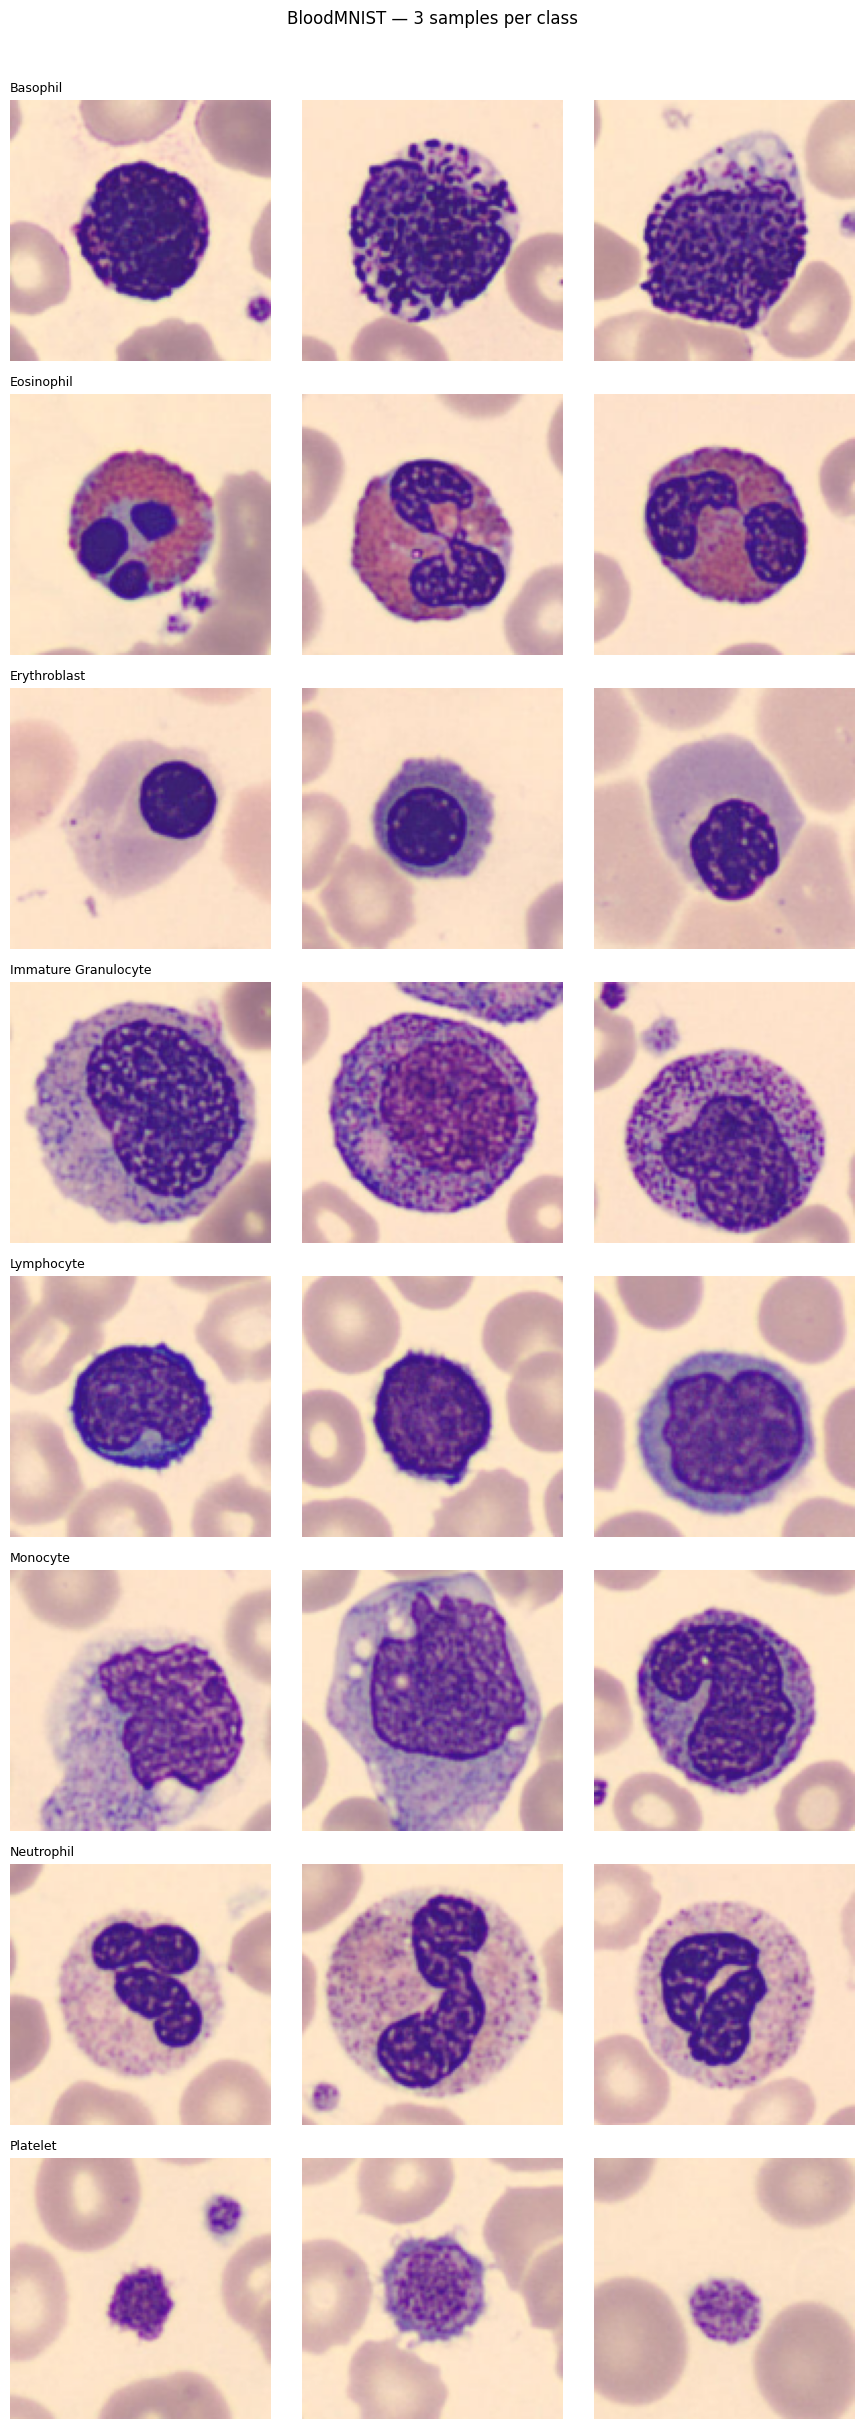

In [24]:
for idx, (_, label) in enumerate(train_data):
    label = int(label)
    if len(class_indices[label]) < SAMPLES_PER_CLASS:
        class_indices[label].append(idx)
    if all(len(v) == SAMPLES_PER_CLASS for v in class_indices.values()):
        break
    
fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS, figsize=(9, 24))
for cls in range(NUM_CLASSES):
    for s, idx in enumerate(class_indices[cls]):
        img, _ = train_data[idx]
        axes[cls][s].imshow(np.array(img))
        axes[cls][s].axis('off')
        if s == 0:
            axes[cls][s].set_title(CLASS_NAMES[cls], fontsize=9, loc='left')
plt.suptitle('BloodMNIST — 3 samples per class', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
    

# Train Test Split to Simulate Semi-supervised Learning

In [25]:
all_indices = np.arange(len(train_data))
all_labels = np.array([int(label) for _, label in train_data])

/tmp/ipykernel_57/3647829885.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  all_labels = np.array([int(label) for _, label in train_data])


In [26]:
labeled_indices, unlabeled_indices = train_test_split(
    all_indices,
    test_size=0.99,
    stratify=all_labels,
    random_state=42
)

In [27]:
labeled_indices

array([ 5552,  7461,  7696,   890,  4284,  8100,  8226,  1928, 11262,
        6830,  5646, 10159,  4791,  5082,  2662,  5257,  9993,  3963,
         543,  8215,  6114, 10515,  4136, 10629,     4,  4817, 10267,
        7105,  3997,  4305,  6410,  5951,  9878, 11677,  6205,  7534,
        8878,  7937,  6399,  4569,  3603, 10300,  9295,  2791, 11148,
        7868,  4218,  6957,  7355,  8738,  1512,  5844,  2686, 11781,
        5013,  7048,  4156,  3007,  9262,  1824,  2845,  9867,  1926,
        9024,  9622, 11375,  1950,  8299,  4095,  8129,  9056,  2090,
        6407,  9805,  6539,  9952,  9837,  7574,  4298,  3429,  6752,
        9074,  3025,  1279,  2655,  1469,  3888,  5051,  2489,  4611,
        4746,  1303,  1065,  5760,   576,  8752,   452, 11622,  8000,
        3238,   280,  2047,  1954,  1821,  1302,  2723, 11739,  1077,
        9255,  3053,  2248,  5059,  4557,  3925,  5277,  5754,   600,
        2928,  6284])

In [28]:
print(f"Labeled   : {len(labeled_indices)}")
print(f"Unlabeled : {len(unlabeled_indices)}")

# Per-class count in labeled set
print("\nPer-class count in labeled set:")
labeled_labels = all_labels[labeled_indices]
for cls in range(NUM_CLASSES):
    count = (labeled_labels == cls).sum()
    print(f"  {CLASS_NAMES[cls]:<28} : {count}")

Labeled   : 119
Unlabeled : 11840

Per-class count in labeled set:
  Basophil                     : 9
  Eosinophil                   : 22
  Erythroblast                 : 11
  Immature Granulocyte         : 20
  Lymphocyte                   : 8
  Monocyte                     : 10
  Neutrophil                   : 23
  Platelet                     : 16


# Setting Up Dataset and Dataloaders

In [29]:
class LabeledDataset(Dataset):
    """
    Returns (weakly_augmented_image, label) for labeled training samples.
    """
    def __init__(self, indices, data, transform):
        self.indices   = indices
        self.data      = data
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.data[self.indices[i]]
        return self.transform(img), int(label.item())


In [30]:
class UnlabeledDataset(Dataset):
    """
    Returns (weak_aug_image, strong_aug_image) for unlabeled training samples.
    No label is returned — used for pseudo-label consistency loss.
    """
    def __init__(self, indices, data, weak_transform, strong_transform):
        self.indices          = indices
        self.data             = data
        self.weak_transform   = weak_transform
        self.strong_transform = strong_transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, _ = self.data[self.indices[i]]
        return self.weak_transform(img), self.strong_transform(img)

In [31]:
class TestDataset(Dataset):
    """
    Returns (image, label) for val/test evaluation. No augmentation beyond normalize.
    """
    def __init__(self, data, transform):
        self.data      = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        img, label = self.data[i]
        return self.transform(img), int(label.item())

## Define Augmentations

In [33]:
MEAN = train_images.mean(axis = (0, 1, 2))
STD = train_images.std(axis = (0, 1, 2))
MEAN_UINT8 = (int(MEAN[0]*255), int(MEAN[1]*255), int(MEAN[2]*255))

In [34]:
print(f"MEAN calculated: {MEAN}")
print(f"STD calculated:  {STD}")
print(f"MEAN_UINT8 calculated for padding fill: {MEAN_UINT8}")

MEAN calculated: [0.79604247 0.65960543 0.69635771]
STD calculated:  [0.2257786  0.25864605 0.0957214 ]
MEAN_UINT8 calculated for padding fill: (202, 168, 177)


In [35]:
# Weak aug — used now; strong aug defined in Phase 2
weak_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Pad(padding =16, fill=MEAN_UINT8),
    T.RandomCrop(128, padding=16),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])


In [36]:
# Random strong transform
rand_strong_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Pad(padding=16, fill=MEAN_UINT8),
    T.RandomCrop(128),
    T.RandAugment(num_ops=2, magnitude=9),
    T.ToTensor(),
    T.Normalize(MEAN.tolist(), STD.tolist()),
    T.RandomErasing(p=1.0, scale=(0.0625, 0.0625),
    ratio=(1.0, 1.0), value=0)
    ])

In [37]:
class AlbumentationsAdapter:
    """
    Bridges the gap between PyTorch PIL inputs and Albumentations NumPy inputs [14].
    Ensures that your Albumentations pipeline behaves exactly like a torchvision 
    transform, returning a normalized PyTorch Tensor [14].
    """
    def __init__(self, albumentations_transform):
        self.transform = albumentations_transform

    def __call__(self, img):
        # 1. Convert PIL Image to numpy array (HWC, uint8)
        img_np = np.array(img)
        
        # 2. Apply Albumentations transform (handles normalization & ToTensorV2)
        augmented = self.transform(image=img_np)
        
        # 3. Return the normalized Tensor
        return augmented['image']

In [38]:
hema_strong_pipeline = A.Compose([
    # Spatial/Morphological Layer
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # Use BORDER_REFLECT to mirror background, avoiding black border artifacts [4]
    A.Rotate(limit=180, border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.ElasticTransform(alpha=80, sigma=8, p=0.5),

    # Optical/Staining Layer
    # Hue limit set strictly to 0.02 to prevent destroying clinical color meanings [4]
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, 
                  hue=0.1, p=0.8),
    A.GaussianBlur(blur_limit=3, p=0.2),
    
    # Normalization & Tensor Conversion
    A.Normalize(mean=MEAN.tolist(), std=STD.tolist()),

    
    # Occlusion Layer (Cutout) - Updated for Albumentations 2.x
    A.CoarseDropout(
        num_holes_range=(1, 4),      # Replaces min_holes and max_holes
        hole_height_range=(8, 20),   # Replaces min_height and max_height
        hole_width_range=(8, 20),    # Replaces min_width and max_width
        fill=0,                      # Replaces fill_value
        p=0.5
    ),
    ToTensorV2()
])

# Wrap the Albumentations pipeline in our Adapter class for clean dataset execution
hema_strong_transform = AlbumentationsAdapter(hema_strong_pipeline)

## Class-Weighted Sampler for 1% Labeled Set

In [39]:
class_counts = np.bincount(labeled_labels)
class_counts

array([ 9, 22, 11, 20,  8, 10, 23, 16])

In [40]:
class_weights = 1.0 / class_counts

In [41]:
sample_weights = class_weights[labeled_labels]
sample_weights

array([0.09090909, 0.05      , 0.04545455, 0.04347826, 0.04347826,
       0.04545455, 0.04545455, 0.04347826, 0.09090909, 0.0625    ,
       0.04545455, 0.125     , 0.125     , 0.05      , 0.05      ,
       0.04347826, 0.05      , 0.09090909, 0.04545455, 0.0625    ,
       0.04347826, 0.0625    , 0.0625    , 0.125     , 0.0625    ,
       0.05      , 0.04347826, 0.04347826, 0.1       , 0.04347826,
       0.125     , 0.11111111, 0.04347826, 0.0625    , 0.04545455,
       0.04545455, 0.05      , 0.1       , 0.04545455, 0.04347826,
       0.05      , 0.04545455, 0.04347826, 0.11111111, 0.04347826,
       0.0625    , 0.11111111, 0.125     , 0.0625    , 0.04545455,
       0.04347826, 0.04347826, 0.09090909, 0.125     , 0.05      ,
       0.04545455, 0.0625    , 0.0625    , 0.11111111, 0.0625    ,
       0.04545455, 0.09090909, 0.04545455, 0.04347826, 0.05      ,
       0.05      , 0.09090909, 0.09090909, 0.05      , 0.04545455,
       0.05      , 0.04347826, 0.0625    , 0.04545455, 0.05   

In [42]:
# Create the PyTorch WeightedRandomSampler
# 'replacement=True' is required to allow oversampling of rare classes
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [43]:
# -------------------------------------------------------
# DataLoaders
# -------------------------------------------------------

labeled_dataset   = LabeledDataset(labeled_indices, train_data, weak_transform)
unlabeled_dataset = UnlabeledDataset(unlabeled_indices, train_data,
                                     weak_transform, rand_strong_transform)
val_dataset       = TestDataset(val_data,  eval_transform)
test_dataset      = TestDataset(test_data, eval_transform)

labeled_loader   = DataLoader(labeled_dataset,   batch_size=16, drop_last=True,  num_workers=0)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=64, drop_last=True,  num_workers=0)
val_loader       = DataLoader(val_dataset,       batch_size=64, shuffle=False, drop_last=False, num_workers=0)
test_loader      = DataLoader(test_dataset,      batch_size=64, shuffle=False, drop_last=False, num_workers=0)

# Cycling unlabeled loader for training loop
unlabeled_cycle = itertools.cycle(unlabeled_loader)

# --- Sanity check ---
imgs_l, labels_l = next(iter(labeled_loader))
imgs_wu, imgs_su = next(iter(unlabeled_loader))

print(f"\nLabeled batch   — images: {imgs_l.shape}, labels: {labels_l.shape}")
print(f"Unlabeled batch — weak: {imgs_wu.shape}, strong: {imgs_su.shape}")
print(f"Val batch       — images: {next(iter(val_loader))[0].shape}")


print(f"Class counts in 1% labeled split: {class_counts}")
print("✔ Labeled DataLoader successfully updated with a WeightedRandomSampler!")



Labeled batch   — images: torch.Size([16, 3, 128, 128]), labels: torch.Size([16])
Unlabeled batch — weak: torch.Size([64, 3, 128, 128]), strong: torch.Size([64, 3, 128, 128])
Val batch       — images: torch.Size([64, 3, 128, 128])
Class counts in 1% labeled split: [ 9 22 11 20  8 10 23 16]
✔ Labeled DataLoader successfully updated with a WeightedRandomSampler!


In [44]:
# ============================================================
# SECTION 1 — End-to-End Data Contract Verification
# ============================================================

def verify_batch(name, batch, expected_image_shape, expect_label=True):
    if expect_label:
        imgs, labels = batch
        print(f"\n{name}")
        print(f"  images : {imgs.shape}, dtype={imgs.dtype}")
        print(f"  labels : {labels.shape}, dtype={labels.dtype}")
        assert imgs.shape[1:] == expected_image_shape, f"Wrong image shape: {imgs.shape}"
        assert labels.dtype == torch.long, f"Labels must be long, got {labels.dtype}"
        assert labels.ndim == 1, f"Labels must be 1D, got shape {labels.shape}"
    else:
        weak, strong = batch
        print(f"\n{name}")
        print(f"  weak   : {weak.shape}, dtype={weak.dtype}")
        print(f"  strong : {strong.shape}, dtype={strong.dtype}")
        assert weak.shape == strong.shape, "Weak and strong shapes must match"
        assert weak.shape[1:] == expected_image_shape, f"Wrong image shape: {weak.shape}"

EXPECTED = torch.Size([3, 128, 128])

verify_batch("LabeledLoader",   next(iter(labeled_loader)),   EXPECTED, expect_label=True)
verify_batch("UnlabeledLoader", next(iter(unlabeled_loader)), EXPECTED, expect_label=False)
verify_batch("ValLoader",       next(iter(val_loader)),       EXPECTED, expect_label=True)
verify_batch("TestLoader",      next(iter(test_loader)),      EXPECTED, expect_label=True)

# Check pixel value range after normalization — should be roughly [-3, 3]
imgs, _ = next(iter(labeled_loader))
print(f"\nNormalized pixel range : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Expected               : roughly [-3.5, 3.5]")

# Check label range
_, labels = next(iter(labeled_loader))
print(f"\nLabel range : [{labels.min()}, {labels.max()}]")
print(f"Expected    : [0, 7]")

print("\n✓ All checks passed — data pipeline is clean")


LabeledLoader
  images : torch.Size([16, 3, 128, 128]), dtype=torch.float32
  labels : torch.Size([16]), dtype=torch.int64

UnlabeledLoader
  weak   : torch.Size([64, 3, 128, 128]), dtype=torch.float32
  strong : torch.Size([64, 3, 128, 128]), dtype=torch.float32

ValLoader
  images : torch.Size([64, 3, 128, 128]), dtype=torch.float32
  labels : torch.Size([64]), dtype=torch.int64

TestLoader
  images : torch.Size([64, 3, 128, 128]), dtype=torch.float32
  labels : torch.Size([64]), dtype=torch.int64

Normalized pixel range : [-7.275, 1.329]
Expected               : roughly [-3.5, 3.5]

Label range : [1, 7]
Expected    : [0, 7]

✓ All checks passed — data pipeline is clean


In [45]:

# ============================================================
# ResNet-18 (Primary Backbone) Setup
# ============================================================

def get_resnet18_backbone(num_classes=8):
    """
    Instantiates a non-pretrained ResNet-18 model via timm.
    The final fully connected linear layer is automatically configured 
    to output logits for your target classes (8 for BloodMNIST).
    """
    model = timm.create_model(
        'resnet18', 
        pretrained=True, 
        num_classes=num_classes
    )
    return model

def count_parameters(model):
    """
    Calculates the total number of active, trainable parameters.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [46]:
# 1. Instantiate the model
model = get_resnet18_backbone(num_classes=8)

# 2. Count parameters to verify network capacity
total_params = count_parameters(model)
print(f"Model Parameter Count: {total_params / 1e6:.2f}M parameters (Expected: ~11.2M)")

# 3. Move model to your Kaggle P100 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model successfully moved to: {device}")


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Model Parameter Count: 11.18M parameters (Expected: ~11.2M)
Model successfully moved to: cuda


In [47]:
# ============================================================
# Penultimate Feature Extraction Verification (GradCAM)
# ============================================================

# Let's perform a validation dry run to verify the model's forward paths.
# We pass a dummy batch of 2 normalized images of size 128x128.
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(2, 3, 128, 128).to(device)
    
    # Test Path 1: Standard classification forward pass
    dummy_output = model(dummy_input)
    
    # Test Path 2: Feature map extraction right before global pooling.
    # timm natively supports this via 'forward_features'.
    dummy_features = model.forward_features(dummy_input)


In [48]:
# Display verification results
print("\n=== Model Data Contract Verification ===")
print(f"Input batch shape:           {dummy_input.shape}")
print(f"Classification logits shape: {dummy_output.shape} (Expected: [batch_size, 8])")
print(f"Penultimate feature shape:   {dummy_features.shape} (Expected: [batch_size, 512, 4, 4])")
print("========================================")
print("✔ Data contract verified successfully!")



=== Model Data Contract Verification ===
Input batch shape:           torch.Size([2, 3, 128, 128])
Classification logits shape: torch.Size([2, 8]) (Expected: [batch_size, 8])
Penultimate feature shape:   torch.Size([2, 512, 4, 4]) (Expected: [batch_size, 512, 4, 4])
✔ Data contract verified successfully!


## Shared Utilities

In [49]:
def cycle(dataloader):
    """
    A memory-safe generator that yields batches infinitely [5.1].
    Unlike itertools.cycle, this does NOT cache batches in CPU RAM,
    preventing massive memory leaks over hundreds of epochs.
    """
    while True:
        for batch in dataloader:
            yield batch

In [50]:
class FreeMatchThreshold:
    """
    Self-adaptive per-class thresholding for FixMatch.
    Replaces global tau=0.95 with per-class thresholds
    that adapt based on each class's learning progress.
    """
    def __init__(self, num_classes=8, momentum=0.9, device='cuda'):
        self.num_classes = num_classes
        self.momentum    = momentum
        self.device      = device
        # Initialize uniformly — 1/num_classes each
        self.class_thresh = torch.ones(num_classes, device=device) / num_classes
        self.history      = []  # for logging

    def update(self, probs):
        """probs: softmax output (batch_size, num_classes)"""
        with torch.no_grad():
            batch_mean = probs.mean(dim=0)
            self.class_thresh = (self.momentum * self.class_thresh
                                 + (1 - self.momentum) * batch_mean)

    def get_mask(self, probs, pseudo_labels):
        """Returns float mask where per-class confidence threshold is met."""
        with torch.no_grad():
            global_thresh  = self.class_thresh.mean()
            normalized     = self.class_thresh / (global_thresh + 1e-6)
            confidence, _  = probs.max(dim=1)
            sample_thresh  = normalized[pseudo_labels]
            mask = confidence.ge(global_thresh * sample_thresh).float()
        return mask

    def log_thresholds(self, epoch, class_names):
        global_thresh = self.class_thresh.mean().item()
        print(f"\n[FreeMatch] Epoch {epoch} — Per-class thresholds "
              f"(global mean: {global_thresh:.4f}):")
        snapshot = {}
        for cls, thresh in enumerate(self.class_thresh):
            t = thresh.item()
            flag = " ←" if t < global_thresh else ""
            print(f"  {class_names[cls]:<28}: {t:.4f}{flag}")
            snapshot[class_names[cls]] = t
        self.history.append({'epoch': epoch, **snapshot})

In [51]:
def test_freematch():
    """
    Unit tests for FreeMatchThreshold.
    Run once before training to verify correctness.
    """
    print("=== FreeMatch Sanity Tests ===\n")
    fm = FreeMatchThreshold(num_classes=8, momentum=0.9, device='cpu')

    # Test 1: Initial thresholds are uniform
    expected = 1.0 / 8
    assert torch.allclose(fm.class_thresh,
                          torch.full((8,), expected), atol=1e-6), \
        "FAIL: Initial thresholds not uniform"
    print("✓ Test 1 passed: Initial thresholds uniform (0.125 each)")

    # Test 2: Update moves threshold toward batch mean
    # Simulate model always confident about class 0
    fake_probs = torch.zeros(16, 8)
    fake_probs[:, 0] = 0.9
    fake_probs[:, 1:] = 0.1 / 7
    fm.update(fake_probs)
    assert fm.class_thresh[0] > fm.class_thresh[1], \
        "FAIL: Class 0 threshold should be highest after update"
    print("✓ Test 2 passed: Threshold updates toward batch distribution")

    # Test 3: Rare class gets lower threshold (more pseudo-labels allowed)
    fm2 = FreeMatchThreshold(num_classes=8, momentum=0.9, device='cpu')
    # Simulate 50 steps: model rarely confident about class 5 (Monocyte)
    for _ in range(50):
        probs = torch.ones(16, 8) * 0.05
        probs[:, 0] = 0.65   # model loves class 0
        probs[:, 5] = 0.01   # model avoids class 5
        probs = probs / probs.sum(dim=1, keepdim=True)
        fm2.update(probs)
    assert fm2.class_thresh[5] < fm2.class_thresh[0], \
        "FAIL: Rare class should have lower threshold"
    print("✓ Test 3 passed: Rare class gets lower threshold (less starvation)")

    # Test 4: Mask is float and correct shape
    probs        = torch.softmax(torch.randn(32, 8), dim=1)
    pseudo       = probs.argmax(dim=1)
    fm2.update(probs)
    mask = fm2.get_mask(probs, pseudo)
    assert mask.shape == (32,),       "FAIL: Wrong mask shape"
    assert mask.dtype == torch.float32, "FAIL: Mask must be float32"
    assert mask.max() <= 1.0 and mask.min() >= 0.0, "FAIL: Mask out of [0,1]"
    print("✓ Test 4 passed: Mask shape, dtype, and range correct")

    # Test 5: Mask ratio is reasonable (not 0%, not 100%)
    probs_high = torch.softmax(torch.randn(64, 8) * 3, dim=1)  # sharper
    pseudo_high = probs_high.argmax(dim=1)
    mask_high = fm2.get_mask(probs_high, pseudo_high)
    ratio = mask_high.mean().item()
    assert 0.0 < ratio < 1.0, f"FAIL: Degenerate mask ratio {ratio:.2f}"
    print(f"✓ Test 5 passed: Mask ratio is non-degenerate ({ratio*100:.1f}%)")

    print("\n=== All tests passed — FreeMatch is safe to use ===\n")

test_freematch()

=== FreeMatch Sanity Tests ===

✓ Test 1 passed: Initial thresholds uniform (0.125 each)
✓ Test 2 passed: Threshold updates toward batch distribution
✓ Test 3 passed: Rare class gets lower threshold (less starvation)
✓ Test 4 passed: Mask shape, dtype, and range correct
✓ Test 5 passed: Mask ratio is non-degenerate (93.8%)

=== All tests passed — FreeMatch is safe to use ===



In [53]:
def plot_threshold_evolution(free_thresh, class_names, save_path='freematch_thresholds.png'):
    if not free_thresh.history:
        print("No threshold history to plot.")
        return
    
    epochs = [h['epoch'] for h in free_thresh.history]
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for cls in class_names:
        vals = [h[cls] for h in free_thresh.history]
        # Highlight problem classes
        lw    = 2.5 if cls in ['Monocyte', 'Immature Granulocyte'] else 1.0
        style = '-'  if cls in ['Monocyte', 'Immature Granulocyte'] else '--'
        ax.plot(epochs, vals, label=cls, linewidth=lw, linestyle=style)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Per-class threshold')
    ax.set_title('FreeMatch — Per-class Threshold Evolution')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved to {save_path}")



In [54]:
# ============================================================
# Shared Evaluation Utility
# ============================================================

def evaluate_model(model, dataloader, device):
    """
    Evaluates the model on a given dataset.
    Returns: accuracy, macro_f1, true_labels, predicted_labels [4.3].
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            # Forward pass
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            
            # Store predictions and true labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Calculate target metrics
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return acc, macro_f1, all_labels, all_preds

In [55]:
def plot_colorful_confusion_matrix(true_labels, pred_labels, class_names, run_name, save_path=None):
    """
    Plots a high-resolution, colorful confusion matrix using Seaborn.
    Saves the image as a 300 DPI print-ready PNG if save_path is provided [10.3].
    """
    # 1. Compute the raw confusion matrix array
    cm = confusion_matrix(true_labels, pred_labels)
    
    # 2. Set up the figure with high resolution
    plt.figure(figsize=(10, 8), dpi=150)
    
    # 3. Create the heatmap
    # We use "Purples" to match the Giemsa stain aesthetic of your blood cells!
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Purples", 
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar=True,
        square=True,
        annot_kws={"size": 11, "weight": "bold"}  # Bold text inside cells for readability
    )
    
    # 4. Add titles and labels with appropriate padding and font sizes
    plt.title(f"Confusion Matrix: {run_name}", fontsize=14, pad=20, weight="bold")
    plt.xlabel("Predicted Cell Type", fontsize=12, labelpad=10, weight="bold")
    plt.ylabel("True Cell Type", fontsize=12, labelpad=10, weight="bold")
    
    # 5. Rotate class names on axes so they never overlap
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    # 6. Adjust layout and save/show
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)  # 300 DPI is standard for print publications
        print(f"  ✔ Publication-ready figure saved to: {save_path}")
    plt.show()

In [56]:
import os
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
from IPython.display import display

def style_max(s):
    """
    Custom styling function to highlight the maximum value in each column.
    Uses an extremely soft, matte slate-gray background, deep charcoal text,
    and bold typography for a professional, academic look.
    """
    is_max = s == s.max()
    # Return CSS style rules for the maximum cells, empty string for others
    return [
        'background-color: #f1f5f9; color: #0f172a; font-weight: bold;' if v else '' 
        for v in is_max
    ]

def log_run_results(run_name, true_labels, pred_labels, test_acc, test_f1, csv_path="hema_results_summary.csv"):
    """
    Programmatically calculates overall and class-specific metrics, saves them 
    to a persistent CSV file, and displays a styled table in the notebook.
    """
    # 1. Compute macro precision and recall
    macro_prec = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    macro_rec = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    
    # 2. Compute per-class F1-scores
    class_f1s = f1_score(true_labels, pred_labels, average=None, zero_division=0)
    
    # 3. Create a dictionary for this run's results
    new_row = {
        "Method": run_name,
        "Accuracy": test_acc,
        "Macro Precision": macro_prec,
        "Macro Recall": macro_rec,
        "Macro F1": test_f1
    }
    
    # Add per-class F1 columns dynamically
    for i, class_name in enumerate(CLASS_NAMES):
        new_row[f"{class_name} F1"] = class_f1s[i]
        
    # 4. Load existing CSV or initialize a new one
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
    else:
        df = pd.DataFrame(columns=list(new_row.keys()))
        
    # 5. Prevent duplicates
    if run_name in df["Method"].values:
        idx = df[df["Method"] == run_name].index[0]
        for col, val in new_row.items():
            df.at[idx, col] = val
        print(f"✔ Updated existing metrics for '{run_name}' in {csv_path}.")
    else:
        new_row_df = pd.DataFrame([new_row])
        df = pd.concat([df, new_row_df], ignore_index=True)
        print(f"✔ Successfully logged new metrics for '{run_name}' to {csv_path}.")
        
    # 6. Save back to persistent CSV file
    df.to_csv(csv_path, index=False)
    
    # 7. Set up visual styling for the Jupyter notebook
    format_dict = {
        "Accuracy": "{:.2%}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    }
    for class_name in CLASS_NAMES:
        format_dict[f"{class_name} F1"] = "{:.4f}"
        
    # Apply custom, ultra-soft styling to columns (excluding the 'Method' column)
    styled_df = df.style.format(format_dict).apply(
        style_max, 
        subset=[col for col in df.columns if col != "Method"], 
        axis=0
    )
    
    print("\n=== PERSISTENT METHODOLOGY LEADERBOARD ===")
    display(styled_df)
    print("==========================================\n")
    
    return df


In [57]:
EPOCHS = 300

## Standard FixMatch Baseline

In [58]:
run_name = "Standard FixMatch with Adaptive Thresholding"

In [59]:
# ============================================================
# FixMatch Training Utilities
# ============================================================

def get_lambda_ramp(epoch, ramp_epochs=20):
    """
    Linearly ramps up the unlabeled loss weight lambda_u 
    from 0.0 to 1.0 over the first N epochs [5.1].
    """
    if epoch < ramp_epochs:
        return float(epoch) / float(ramp_epochs)
    return 1.0

# Define the best checkpoint name for Standard FixMatch
FIXMATCH_CHECKPOINT = "fixmatch_resnet18_best.pth"

# Freshly re-initialize model for Phase 5 to ensure clean weights [3.1]
model = get_resnet18_backbone(num_classes=8).to(device)

criterion_supervised = nn.CrossEntropyLoss()

# Standard paper optimizer: SGD + Momentum + Weight Decay [2.4, B.1]
optimizer = optim.SGD(
    model.parameters(), 
    lr=0.03, 
    momentum=0.9, 
    weight_decay=1e-4
)

# Cosine Annealing Scheduler over the full 200 epochs [2.4, B.1]
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [61]:
# ============================================================
#  FixMatch Training Loop
# ============================================================

print("--- Starting Standard FixMatch Training (Baseline SSL) ---")
best_val_acc = 0.0
start_time = time.time()

# Create the cycle generator for the larger unlabeled loader [5.1]
unlabeled_cycle = itertools.cycle(unlabeled_loader)
# Fresh FreeMatch instance for this condition
free_thresh = FreeMatchThreshold(
    num_classes=8, momentum=0.9, device=device)
running_mean = None  # reset DA running mean too

for epoch in range(1, 301):
    model.train()
    
    running_loss_s = 0.0
    running_loss_u = 0.0
    running_mask_ratio = 0.0
    steps_in_epoch = 0
    
    # Standard FixMatch step: zip labeled loader with the cycled unlabeled loader [5.1]
    for (labeled_imgs, labels), (weak_unlabeled, strong_unlabeled) in zip(labeled_loader, unlabeled_cycle):
        
        # Move inputs to target device (T4 GPU) [5.1]
        labeled_imgs = labeled_imgs.to(device)
        labels = labels.squeeze().long().to(device)
        
        weak_unlabeled = weak_unlabeled.to(device)
        strong_unlabeled = strong_unlabeled.to(device)
        
        # --------------------------------------------------------
        # Step 1: Calculate Supervised Loss (Weak Augmented Labeled)
        # --------------------------------------------------------
        logits_labeled = model(labeled_imgs)
        loss_supervised = criterion_supervised(logits_labeled, labels)
        
        # --------------------------------------------------------
        # Step 2: Generate Pseudo-Labels (Weak Augmented Unlabeled)
        # Must run under torch.no_grad() to block gradient tracking [5.1]
        # --------------------------------------------------------
        with torch.no_grad():
            logits_weak    = model(weak_unlabeled)
            probs_weak     = torch.softmax(logits_weak, dim=1)
            confidence, pseudo_labels = probs_weak.max(dim=1)
    
            # FreeMatch — update per-class thresholds
            free_thresh.update(probs_weak)
    
            # FreeMatch — get adaptive mask instead of fixed 0.95
            mask = free_thresh.get_mask(probs_weak, pseudo_labels)
    
            
        # --------------------------------------------------------
        # Step 3: Calculate Consistency Loss (Strong Augmented Unlabeled)
        # --------------------------------------------------------
        logits_strong = model(strong_unlabeled)
        
        # Standard Cross-Entropy calculated per sample, multiplied by the active mask [5.1]
        raw_loss_u = F.cross_entropy(logits_strong, pseudo_labels, reduction='none')
        loss_unsupervised = (raw_loss_u * mask).mean()
        
        # --------------------------------------------------------
        # Step 4: Combine Losses with Lambda Ramp-Up [5.1]
        # --------------------------------------------------------
        lambda_u = get_lambda_ramp(epoch, ramp_epochs=20)
        total_loss = loss_supervised + lambda_u * loss_unsupervised
        
        # Gradient Update Step
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        # Track running metrics
        running_loss_s += loss_supervised.item()
        running_loss_u += loss_unsupervised.item()
        running_mask_ratio += mask.mean().item()  # Percentage of batch above 0.95
        steps_in_epoch += 1
        
    # Decay learning rate [4.2]
    scheduler.step()
    
    # Calculate epoch-level averages
    epoch_loss_s = running_loss_s / steps_in_epoch
    epoch_loss_u = running_loss_u / steps_in_epoch
    epoch_mask_ratio = running_mask_ratio / steps_in_epoch
    
    # Evaluate and print metrics every 10 epochs [5.1]
    if epoch % 10 == 0 or epoch == 1:
        val_acc, val_f1, _, _ = evaluate_model(model, val_loader, device)
        print(f"Epoch {epoch:03d}/{EPOCHS} | Loss S: {epoch_loss_s:.4f} | Loss U: {epoch_loss_u:.4f} | "
              f"Mask Ratio: {epoch_mask_ratio*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
        if epoch % 20 == 0:
            free_thresh.log_thresholds(epoch, CLASS_NAMES)
        
        # Save best model checkpoint based on validation accuracy [5.1]
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_f1': val_f1,
                'mask_ratio': epoch_mask_ratio
            }, FIXMATCH_CHECKPOINT)
            print(f"  ✔ New best model saved to {FIXMATCH_CHECKPOINT} (Val Acc: {val_acc*100:.2f}%)")

training_duration = time.time() - start_time
print(f"\nStandard FixMatch training completed in {training_duration/60:.2f} minutes!")
print(f"Best Validation Accuracy achieved: {best_val_acc*100:.2f}%")

--- Starting Standard FixMatch Training (Baseline SSL) ---
Epoch 001/300 | Loss S: 2.0294 | Loss U: 1.5863 | Mask Ratio: 100.00% | Val Acc: 31.89% | Val F1: 0.1751
  ✔ New best model saved to fixmatch_resnet18_best.pth (Val Acc: 31.89%)
Epoch 010/300 | Loss S: 0.1225 | Loss U: 0.7728 | Mask Ratio: 100.00% | Val Acc: 83.06% | Val F1: 0.7633
  ✔ New best model saved to fixmatch_resnet18_best.pth (Val Acc: 83.06%)
Epoch 020/300 | Loss S: 0.0524 | Loss U: 0.5888 | Mask Ratio: 100.00% | Val Acc: 91.30% | Val F1: 0.9004

[FreeMatch] Epoch 20 — Per-class thresholds (global mean: 0.1250):
  Basophil                    : 0.0882 ←
  Eosinophil                  : 0.1816
  Erythroblast                : 0.0853 ←
  Immature Granulocyte        : 0.1713
  Lymphocyte                  : 0.0721 ←
  Monocyte                    : 0.0709 ←
  Neutrophil                  : 0.1961
  Platelet                    : 0.1346
  ✔ New best model saved to fixmatch_resnet18_best.pth (Val Acc: 91.30%)
Epoch 030/300 | Los

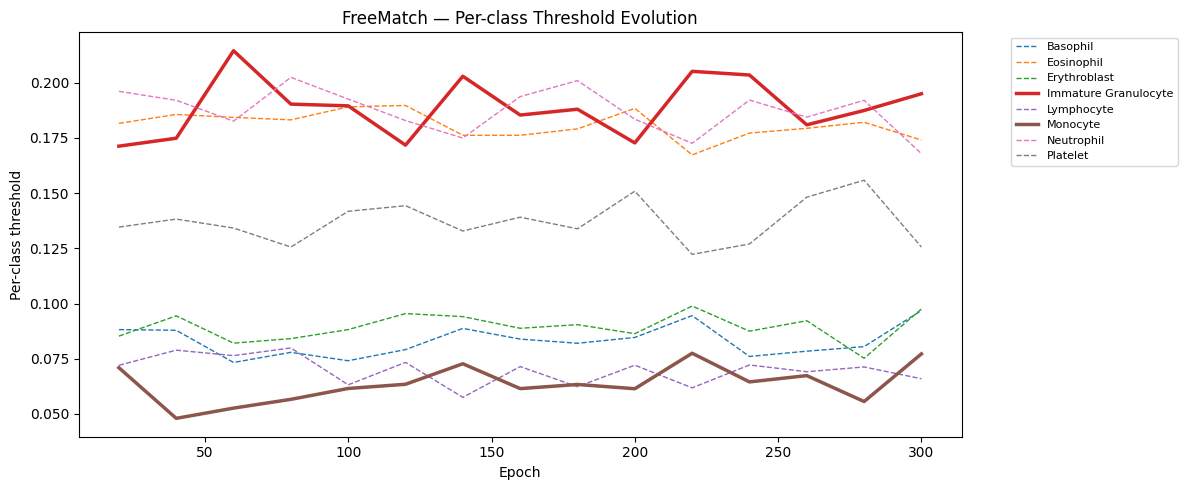

Saved to freematch_thresholds.png


In [62]:
plot_threshold_evolution(free_thresh, CLASS_NAMES)


--- Running Final Evaluation on Test Set ---
Loaded best checkpoint from epoch 210 with Val Acc 94.68%

=== Standard FixMatch Test Set Performance ===
Overall Test Accuracy : 92.66%
Macro F1-Score        : 0.9186

Detailed Per-Class Performance:
                      precision    recall  f1-score   support

            Basophil       0.94      0.97      0.96       244
          Eosinophil       1.00      0.99      0.99       624
        Erythroblast       0.91      0.91      0.91       311
Immature Granulocyte       0.77      0.90      0.83       579
          Lymphocyte       0.97      0.95      0.96       243
            Monocyte       0.87      0.65      0.74       284
          Neutrophil       0.98      0.94      0.96       666
            Platelet       1.00      0.99      0.99       470

            accuracy                           0.93      3421
           macro avg       0.93      0.91      0.92      3421
        weighted avg       0.93      0.93      0.93      3421


Gener

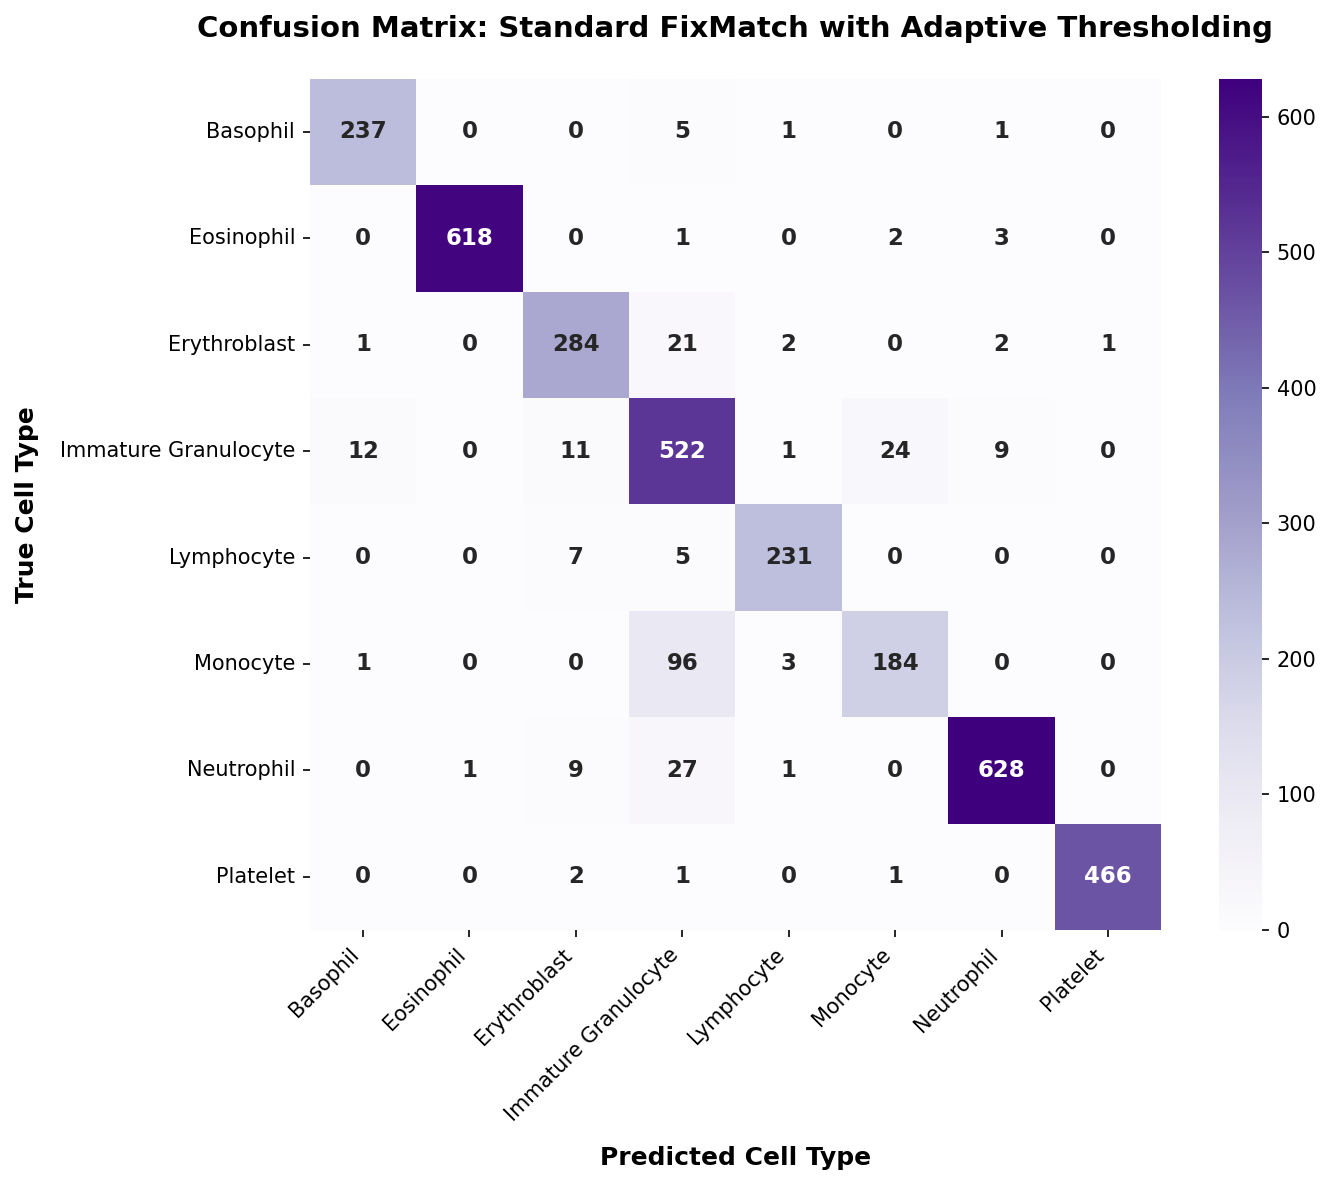

✔ Successfully logged new metrics for 'Standard FixMatch with Adaptive Thresholding' to hema_results_summary.csv.

=== PERSISTENT METHODOLOGY LEADERBOARD ===


/tmp/ipykernel_57/2516879777.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row_df], ignore_index=True)


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,92.66%,0.9291,0.9137,0.9186,0.9576,0.9944,0.9103,0.8305,0.9585,0.7434,0.9595,0.9947


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,0.92663,0.92912,0.913671,0.918608,0.957576,0.994368,0.910256,0.830549,0.958506,0.743434,0.959511,0.994664


In [63]:
# ============================================================
# Final Baseline SSL Evaluation
# ============================================================

print("\n--- Running Final Evaluation on Test Set ---")

# 1. Load the best saved checkpoint [4.3]
checkpoint = torch.load(FIXMATCH_CHECKPOINT)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} with Val Acc {checkpoint['val_acc']*100:.2f}%")

# 2. Run evaluation on test set [4.3]
test_acc, test_f1, true_labels, pred_labels = evaluate_model(model, test_loader, device)

# 3. Compile and report metrics [4.3]
print("\n=== Standard FixMatch Test Set Performance ===")
print(f"Overall Test Accuracy : {test_acc*100:.2f}%")
print(f"Macro F1-Score        : {test_f1:.4f}")
print("================================================")

print("\nDetailed Per-Class Performance:")
print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))

# Define an automatic, descriptive filename for saving
save_filename = f"{run_name.lower().replace(' ', '_').replace('+', 'and')}_confusion_matrix.png"

# Generate the beautiful colorful plot
print("\nGenerating Confusion Matrix Plot...")
plot_colorful_confusion_matrix(
    true_labels=true_labels, 
    pred_labels=pred_labels, 
    class_names=CLASS_NAMES, 
    run_name=run_name,
    save_path=save_filename
)

log_run_results(
    run_name=run_name,
    true_labels=true_labels,
    pred_labels=pred_labels,
    test_acc=test_acc,
    test_f1=test_f1
)

## HemaMatch + DA

In [64]:
run_name = "Hema-Aug with Adaptive Thresholding"

In [65]:
# ============================================================
# SECTION 6.0 — Rebuild Unlabeled Loader with Hema-Aug
# ============================================================

# We swap the strong transform from standard RandAugment to Hema-Aug [6.1]
hema_unlabeled_dataset = UnlabeledDataset(
    unlabeled_indices, 
    train_data,
    weak_transform,             # Kept identical to Phase 5
    hema_strong_transform       # Our custom AlbumentationsAdapter pipeline [4]
)

# Re-instantiate the dataloader with the new Hema-Aug dataset
hema_unlabeled_loader = DataLoader(
    hema_unlabeled_dataset, 
    batch_size=64,              # Kept identical [1.5]
    shuffle=True, 
    drop_last=True, 
    num_workers=0
)

# Re-create the cycle generator using the new Hema-Aug loader
# Use our new memory-safe generator to prevent RAM caching
hema_unlabeled_cycle = cycle(hema_unlabeled_loader)


In [66]:
# ============================================================
# SECTION 6.1 — Phase 6 Training Setup
# ============================================================

HEMA_AUG_ONLY_CHECKPOINT = "hemamatch_aug_only_best.pth"

# Freshly re-initialize model for Phase 6 to ensure clean weights [3.1]
model = get_resnet18_backbone(num_classes=8).to(device)

criterion_supervised = nn.CrossEntropyLoss()

# Standard paper optimizer (identical to Phase 5) [6.1]
optimizer = optim.SGD(
    model.parameters(), 
    lr=0.03, 
    momentum=0.9, 
    weight_decay=1e-4
)

# Cosine Annealing Scheduler (identical to Phase 5) [6.1]
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)


In [67]:
print("--- Starting HemaMatch Training: Phase 6 (Hema-Aug with Adaptive Thresholding) ---")
best_val_acc = 0.0
start_time = time.time()
free_thresh = FreeMatchThreshold(
num_classes=8, momentum=0.9, device=device)

for epoch in range(1, 301):
    model.train()
    
    running_loss_s = 0.0
    running_loss_u = 0.0
    running_mask_ratio = 0.0
    steps_in_epoch = 0
    
    # Zip labeled loader with the new Hema-Aug cycle [6.1]
    for (labeled_imgs, labels), (weak_unlabeled, strong_unlabeled) in zip(labeled_loader, hema_unlabeled_cycle):
        
        labeled_imgs = labeled_imgs.to(device)
        labels = labels.squeeze().long().to(device)
        
        weak_unlabeled = weak_unlabeled.to(device)
        strong_unlabeled = strong_unlabeled.to(device)
        
        # Step 1: Supervised Loss
        logits_labeled = model(labeled_imgs)
        loss_supervised = criterion_supervised(logits_labeled, labels)
        
        # Step 2: Pseudo-Label Generation (Weak Unlabeled)
        with torch.no_grad():
            logits_weak    = model(weak_unlabeled)
            probs_weak     = torch.softmax(logits_weak, dim=1)
            confidence, pseudo_labels = probs_weak.max(dim=1)
    
            # FreeMatch — update per-class thresholds
            free_thresh.update(probs_weak)
    
            # FreeMatch — get adaptive mask instead of fixed 0.95
            mask = free_thresh.get_mask(probs_weak, pseudo_labels)
    
            
            
        # Step 3: Consistency Loss using Hema-Aug (Strong Unlabeled)
        logits_strong = model(strong_unlabeled)
        raw_loss_u = F.cross_entropy(logits_strong, pseudo_labels, reduction='none')
        loss_unsupervised = (raw_loss_u * mask).mean()
        
        # Step 4: Combined Loss with Lambda Ramp-Up
        lambda_u = get_lambda_ramp(epoch, ramp_epochs=20)
        total_loss = loss_supervised + lambda_u * loss_unsupervised
        
        # Gradient Update
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        running_loss_s += loss_supervised.item()
        running_loss_u += loss_unsupervised.item()
        running_mask_ratio += mask.mean().item()
        steps_in_epoch += 1
        
    scheduler.step()
    
    epoch_loss_s = running_loss_s / steps_in_epoch
    epoch_loss_u = running_loss_u / steps_in_epoch
    epoch_mask_ratio = running_mask_ratio / steps_in_epoch
    
    # Evaluate every 10 epochs [6.2]
    if epoch % 10 == 0 or epoch == 1:
        val_acc, val_f1, _, _ = evaluate_model(model, val_loader, device)
        print(f"Epoch {epoch:03d}/300 | Loss S: {epoch_loss_s:.4f} | Loss U: {epoch_loss_u:.4f} | "
              f"Mask Ratio: {epoch_mask_ratio*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
        if epoch % 20 == 0:
            free_thresh.log_thresholds(epoch, CLASS_NAMES)
            
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'val_f1': val_f1,
                'mask_ratio': epoch_mask_ratio
            }, HEMA_AUG_ONLY_CHECKPOINT)
            print(f"  ✔ New best model saved to {HEMA_AUG_ONLY_CHECKPOINT} (Val Acc: {val_acc*100:.2f}%)")

training_duration = time.time() - start_time
print(f"\nHema-Aug training completed in {training_duration/60:.2f} minutes!")
print(f"Best Validation Accuracy achieved: {best_val_acc*100:.2f}%")

--- Starting HemaMatch Training: Phase 6 (Hema-Aug with Adaptive Thresholding) ---
Epoch 001/300 | Loss S: 2.0683 | Loss U: 1.6245 | Mask Ratio: 100.00% | Val Acc: 39.02% | Val F1: 0.2163
  ✔ New best model saved to hemamatch_aug_only_best.pth (Val Acc: 39.02%)
Epoch 010/300 | Loss S: 0.1502 | Loss U: 0.7984 | Mask Ratio: 100.00% | Val Acc: 85.28% | Val F1: 0.8186
  ✔ New best model saved to hemamatch_aug_only_best.pth (Val Acc: 85.28%)
Epoch 020/300 | Loss S: 0.0712 | Loss U: 0.4539 | Mask Ratio: 100.00% | Val Acc: 87.50% | Val F1: 0.8438

[FreeMatch] Epoch 20 — Per-class thresholds (global mean: 0.1250):
  Basophil                    : 0.0775 ←
  Eosinophil                  : 0.1925
  Erythroblast                : 0.0665 ←
  Immature Granulocyte        : 0.1897
  Lymphocyte                  : 0.0891 ←
  Monocyte                    : 0.0581 ←
  Neutrophil                  : 0.1945
  Platelet                    : 0.1322
  ✔ New best model saved to hemamatch_aug_only_best.pth (Val Acc: 

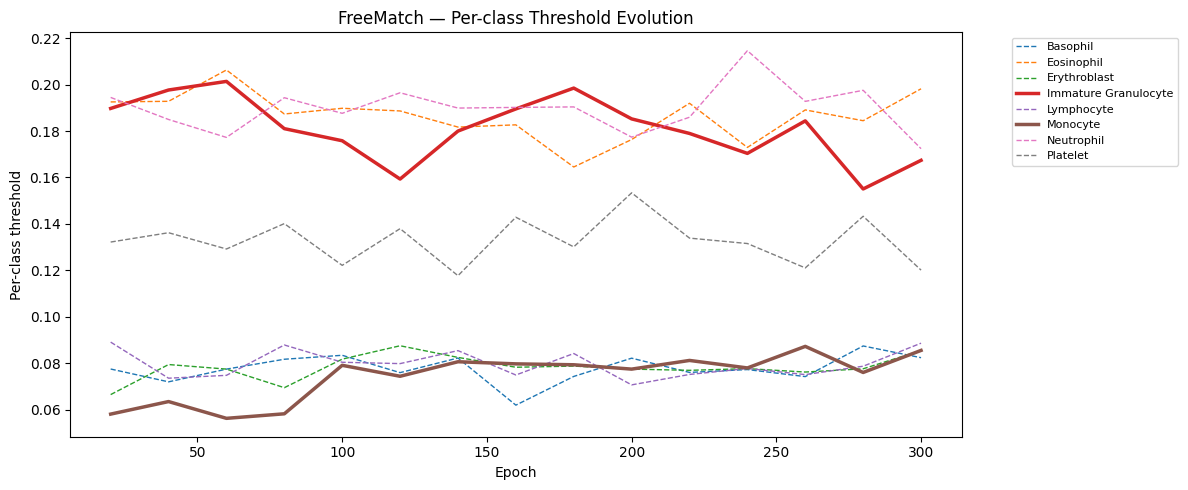

Saved to freematch_thresholds.png


In [68]:
plot_threshold_evolution(free_thresh, CLASS_NAMES)


--- Running Final Evaluation on Test Set ---
Loaded best checkpoint from epoch 190 with Val Acc 95.56%

=== Phase 6 (Hema-Aug Only) Test Set Performance ===
Overall Test Accuracy : 95.06%
Macro F1-Score        : 0.9433

Detailed Per-Class Performance:
                      precision    recall  f1-score   support

            Basophil       0.95      0.99      0.97       244
          Eosinophil       1.00      1.00      1.00       624
        Erythroblast       0.99      0.85      0.92       311
Immature Granulocyte       0.86      0.94      0.90       579
          Lymphocyte       0.86      1.00      0.93       243
            Monocyte       0.94      0.81      0.87       284
          Neutrophil       0.98      0.96      0.97       666
            Platelet       1.00      1.00      1.00       470

            accuracy                           0.95      3421
           macro avg       0.95      0.94      0.94      3421
        weighted avg       0.95      0.95      0.95      3421



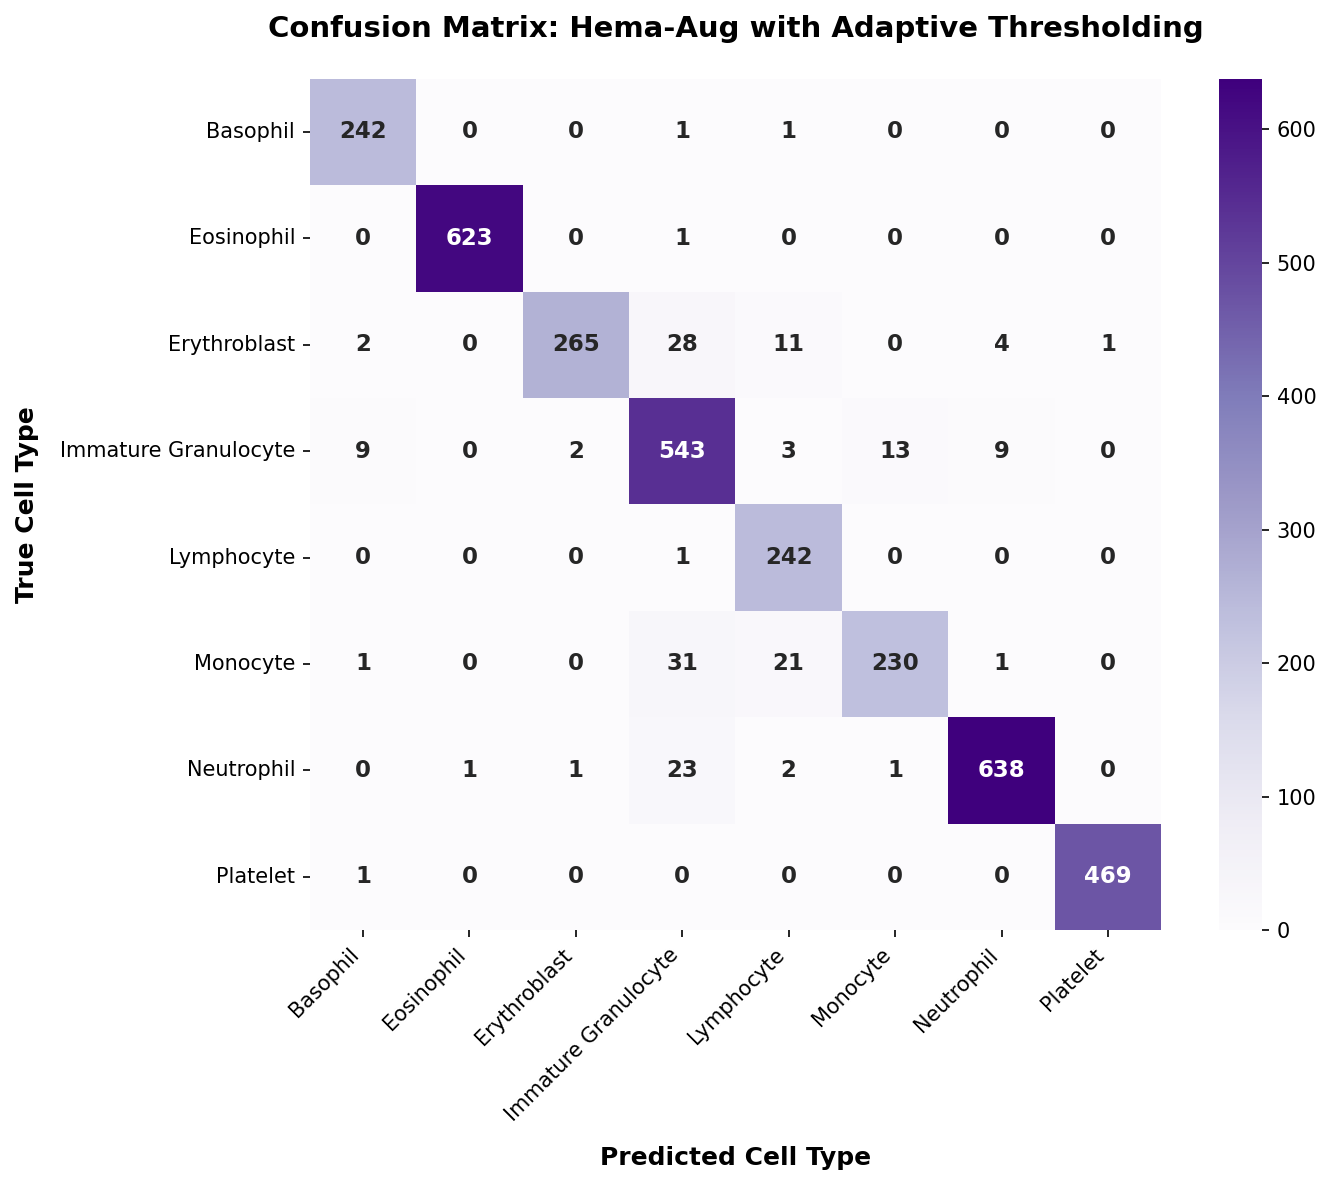

✔ Successfully logged new metrics for 'Hema-Aug with Adaptive Thresholding' to hema_results_summary.csv.

=== PERSISTENT METHODOLOGY LEADERBOARD ===


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,92.66%,0.9291,0.9137,0.9186,0.9576,0.9944,0.9103,0.8305,0.9585,0.7434,0.9595,0.9947
1,Hema-Aug with Adaptive Thresholding,95.06%,0.9480,0.9427,0.9433,0.9699,0.9984,0.9154,0.8998,0.9254,0.8712,0.9681,0.9979


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,0.926630,0.929120,0.913671,0.918608,0.957576,0.994368,0.910256,0.830549,0.958506,0.743434,0.959511,0.994664
1,Hema-Aug with Adaptive Thresholding,0.950599,0.948023,0.942711,0.943264,0.969940,0.998397,0.915371,0.899751,0.925430,0.871212,0.968134,0.997872


In [69]:
# ============================================================
# Final Phase 6 Evaluation
# ============================================================

print("\n--- Running Final Evaluation on Test Set ---")

# Load best checkpoint
checkpoint = torch.load(HEMA_AUG_ONLY_CHECKPOINT)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} with Val Acc {checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
test_acc, test_f1, true_labels, pred_labels = evaluate_model(model, test_loader, device)

print("\n=== Phase 6 (Hema-Aug Only) Test Set Performance ===")
print(f"Overall Test Accuracy : {test_acc*100:.2f}%")
print(f"Macro F1-Score        : {test_f1:.4f}")
print("======================================================")

print("\nDetailed Per-Class Performance:")
print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))

# Define an automatic, descriptive filename for saving
save_filename = f"{run_name.lower().replace(' ', '_').replace('+', 'and')}_confusion_matrix.png"

# Generate the beautiful colorful plot
print("\nGenerating Confusion Matrix Plot...")
plot_colorful_confusion_matrix(
    true_labels=true_labels, 
    pred_labels=pred_labels, 
    class_names=CLASS_NAMES, 
    run_name=run_name,
    save_path=save_filename
)

log_run_results(
    run_name=run_name,
    true_labels=true_labels,
    pred_labels=pred_labels,
    test_acc=test_acc,
    test_f1=test_f1
)

## Distribution Alignment

In [70]:
# ============================================================
# CONFIGURATION TOGGLE: Set this before running
# ============================================================
# FALSE = Phase 7a: Standard FixMatch + DA (uses RandAugment)
# TRUE  = Phase 7b: Full HemaMatch (uses Hema-Aug + DA)
USE_HEMA_AUG = False

In [71]:
# ============================================================
# Dynamic Class Prior Estimation
# ============================================================

# Dynamically estimate the class prior p(y|X) from your labeled training set [D.1]
labeled_labels = []
for _, labels in labeled_loader:
    labeled_labels.extend(labels.squeeze().numpy())

unique_classes, counts = np.unique(labeled_labels, return_counts=True)
prior_counts = np.zeros(8)
for u, c in zip(unique_classes, counts):
    prior_counts[int(u)] = c

# Normalize prior frequencies and move to device [D.1]
class_prior = torch.tensor(prior_counts / prior_counts.sum(), dtype=torch.float32).to(device)
print(f"Estimated Class Prior p(y|X) for 1% split: {class_prior.cpu().numpy()}")

# Select the appropriate dataloader cycle and checkpoint name
if USE_HEMA_AUG:
    active_unlabeled_cycle = hema_unlabeled_cycle  # Hema-Aug loader
    CHECKPOINT_NAME = "hemamatch_full_best.pth"
    run_name = "Full HemaMatch (Hema-Aug + DA)"
else:
    active_unlabeled_cycle = unlabeled_cycle       # Standard RandAugment loader
    CHECKPOINT_NAME = "fixmatch_da_best.pth"
    run_name = "Standard FixMatch + DA"

Estimated Class Prior p(y|X) for 1% split: [0.08035714 0.1875     0.09821428 0.16071428 0.07142857 0.08035714
 0.1875     0.13392857]


In [72]:
# ============================================================
# Model & Training Setup
# ============================================================

# Freshly re-initialize model for Phase 7 to ensure clean weights [3.1]
model = get_resnet18_backbone(num_classes=8).to(device)

criterion_supervised = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(), 
    lr=0.03, 
    momentum=0.9, 
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

# Initialize the running mean prediction vector p_m(y|U) [D.1, 7.1]
running_mean = None


In [73]:
# ============================================================
# Training Loop with Distribution Alignment
# ============================================================

print(f"\n--- Starting Training: {run_name} ---")
best_val_acc = 0.0
start_time = time.time()

# Fresh FreeMatch instance for this condition
free_thresh = FreeMatchThreshold(
num_classes=8, momentum=0.9, device=device)
running_mean = None  # reset DA running mean too

for epoch in range(1, 301):
    model.train()
    
    running_loss_s = 0.0
    running_loss_u = 0.0
    running_mask_ratio = 0.0
    steps_in_epoch = 0
    
    for (labeled_imgs, labels), (weak_unlabeled, strong_unlabeled) in zip(labeled_loader, active_unlabeled_cycle):
        
        labeled_imgs = labeled_imgs.to(device)
        labels = labels.squeeze().long().to(device)
        
        weak_unlabeled = weak_unlabeled.to(device)
        strong_unlabeled = strong_unlabeled.to(device)
        
        # Step 1: Supervised Loss
        logits_labeled = model(labeled_imgs)
        loss_supervised = criterion_supervised(logits_labeled, labels)
        
        # Step 2: Pseudo-Label Generation with Distribution Alignment [D.1, 7.1]
        with torch.no_grad():
            logits_weak = model(weak_unlabeled)
            probs_weak = torch.softmax(logits_weak, dim=1)
            
            # Update running mean p_m(y|U) using EMA momentum of 0.9 [D.1, 7.1]
            if running_mean is None:
                running_mean = probs_weak.mean(dim=0).detach()
            else:
                running_mean = 0.9 * running_mean + 0.1 * probs_weak.mean(dim=0).detach()
                
            # Distribution Alignment scaling: q_tilde = q * (prior / running_mean) [D.1, 7.1]
            probs_aligned = probs_weak * (class_prior / (running_mean + 1e-6))
            probs_aligned = probs_aligned / probs_aligned.sum(dim=1, keepdim=True)  # Re-normalize to sum to 1 [D.1]
            
            # Update FreeMatch thresholds using aligned probs
            free_thresh.update(probs_aligned)

            # FreeMatch adaptive mask on aligned probs
            confidence, pseudo_labels = probs_aligned.max(dim=1)
            mask = free_thresh.get_mask(probs_aligned, pseudo_labels)
            
        # Step 3: Consistency Loss on Strong Unlabeled
        logits_strong = model(strong_unlabeled)
        raw_loss_u = F.cross_entropy(logits_strong, pseudo_labels, reduction='none')
        loss_unsupervised = (raw_loss_u * mask).mean()
        
        # Step 4: Combined Loss with Lambda Ramp-Up
        lambda_u = get_lambda_ramp(epoch, ramp_epochs=20)
        total_loss = loss_supervised + lambda_u * loss_unsupervised
        
        # Gradient Update
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        running_loss_s += loss_supervised.item()
        running_loss_u += loss_unsupervised.item()
        running_mask_ratio += mask.mean().item()
        steps_in_epoch += 1
        
    scheduler.step()
    
    epoch_loss_s = running_loss_s / steps_in_epoch
    epoch_loss_u = running_loss_u / steps_in_epoch
    epoch_mask_ratio = running_mask_ratio / steps_in_epoch
    
    # Evaluate every 10 epochs [5.1]
    if epoch % 10 == 0 or epoch == 1:
        val_acc, val_f1, _, _ = evaluate_model(model, val_loader, device)
        print(f"Epoch {epoch:03d}/{EPOCHS} | Loss S: {epoch_loss_s:.4f} | Loss U: {epoch_loss_u:.4f} | "
              f"Mask Ratio: {epoch_mask_ratio*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
        if epoch % 20 == 0:
            free_thresh.log_thresholds(epoch, CLASS_NAMES)
            print(f"  [DA Running Mean]: {running_mean.cpu().numpy().round(4)}")
        
        # Log running_mean distribution convergence check [7.1]
        if epoch % 50 == 0:
            print(f"  [EMA Running Mean p_m(y|U) Convergence Check]:\n  {running_mean.cpu().numpy()}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'val_f1': val_f1,
                'mask_ratio': epoch_mask_ratio,
                'running_mean': running_mean
            }, CHECKPOINT_NAME)
            print(f"  ✔ New best model saved to {CHECKPOINT_NAME} (Val Acc: {val_acc*100:.2f}%)")

training_duration = time.time() - start_time
print(f"\nTraining completed in {training_duration/60:.2f} minutes!")
print(f"Best Validation Accuracy achieved: {best_val_acc*100:.2f}%")



--- Starting Training: Standard FixMatch + DA ---
Epoch 001/300 | Loss S: 2.0972 | Loss U: 1.6036 | Mask Ratio: 100.00% | Val Acc: 24.01% | Val F1: 0.1158
  ✔ New best model saved to fixmatch_da_best.pth (Val Acc: 24.01%)
Epoch 010/300 | Loss S: 0.1729 | Loss U: 0.9817 | Mask Ratio: 100.00% | Val Acc: 81.89% | Val F1: 0.7851
  ✔ New best model saved to fixmatch_da_best.pth (Val Acc: 81.89%)
Epoch 020/300 | Loss S: 0.0713 | Loss U: 0.4616 | Mask Ratio: 100.00% | Val Acc: 86.04% | Val F1: 0.8322

[FreeMatch] Epoch 20 — Per-class thresholds (global mean: 0.1250):
  Basophil                    : 0.0670 ←
  Eosinophil                  : 0.1843
  Erythroblast                : 0.0941 ←
  Immature Granulocyte        : 0.1952
  Lymphocyte                  : 0.0791 ←
  Monocyte                    : 0.0500 ←
  Neutrophil                  : 0.1991
  Platelet                    : 0.1312
  [DA Running Mean]: [0.0652 0.1841 0.0924 0.2031 0.0813 0.0435 0.1991 0.1313]
  ✔ New best model saved to fixma


--- Running Final Evaluation on Test Set: Standard FixMatch + DA ---
Loaded best checkpoint from epoch 290 with Val Acc 94.45%

=== Standard FixMatch + DA Test Set Performance ===
Overall Test Accuracy : 92.34%
Macro F1-Score        : 0.9144

Detailed Per-Class Performance:
                      precision    recall  f1-score   support

            Basophil       0.96      0.98      0.97       244
          Eosinophil       0.98      1.00      0.99       624
        Erythroblast       0.98      0.86      0.92       311
Immature Granulocyte       0.77      0.91      0.83       579
          Lymphocyte       0.91      1.00      0.95       243
            Monocyte       0.84      0.62      0.71       284
          Neutrophil       0.99      0.92      0.95       666
            Platelet       0.99      1.00      0.99       470

            accuracy                           0.92      3421
           macro avg       0.93      0.91      0.91      3421
        weighted avg       0.93      0.9

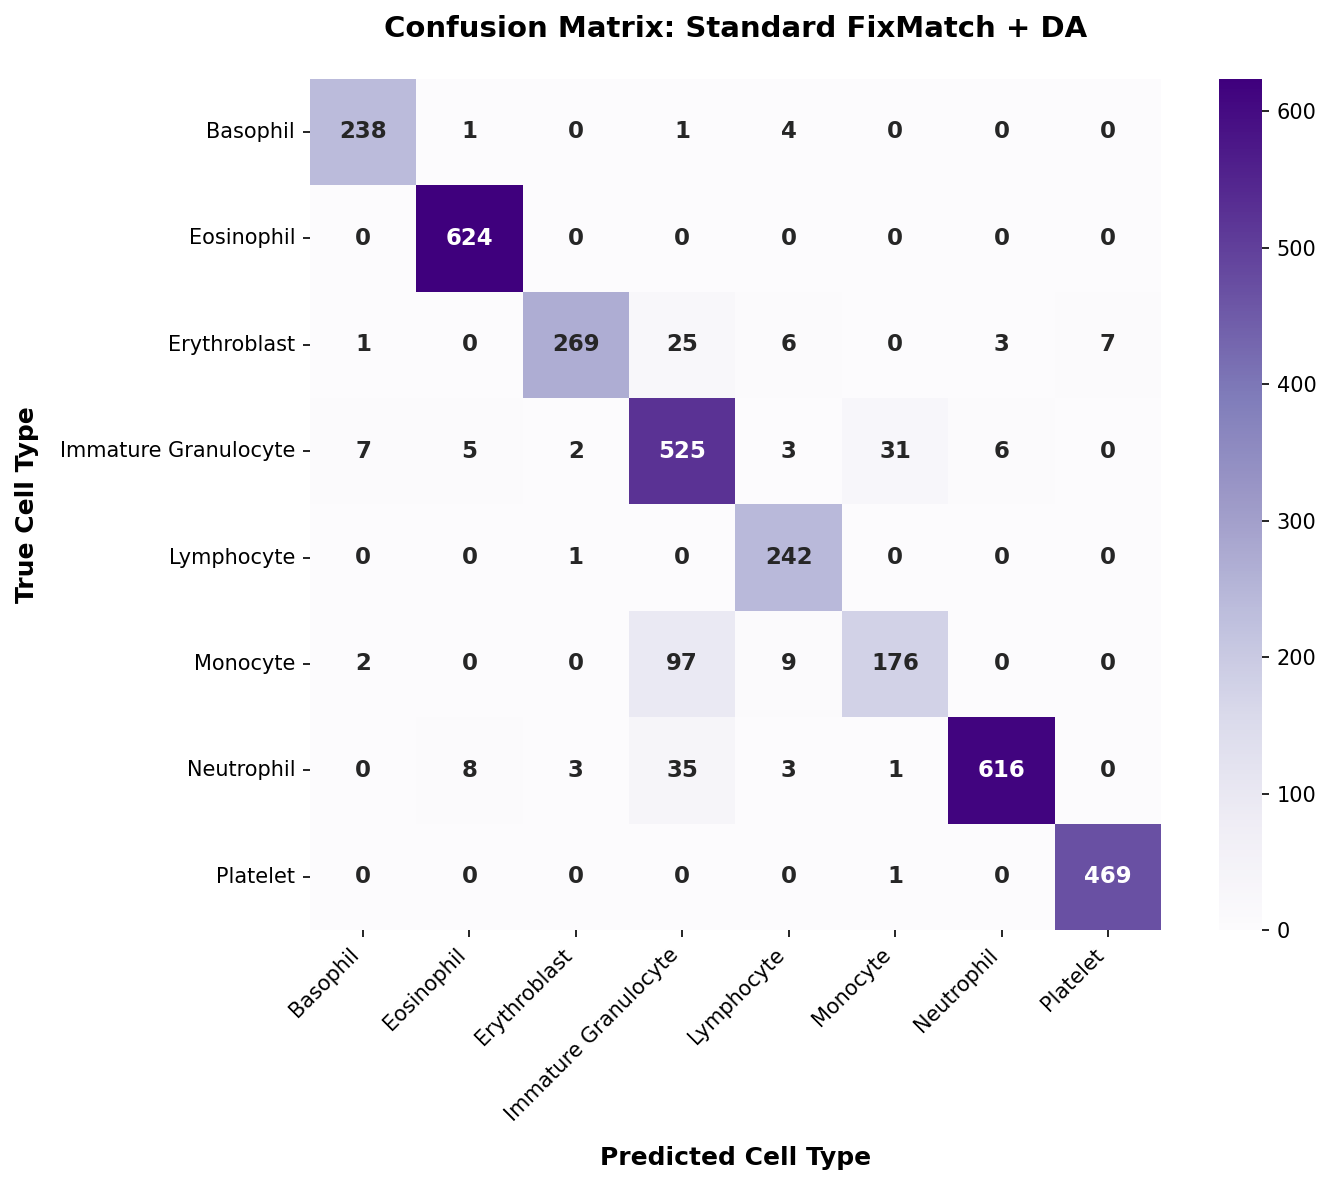

✔ Successfully logged new metrics for 'Standard FixMatch + DA' to hema_results_summary.csv.

=== PERSISTENT METHODOLOGY LEADERBOARD ===


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,92.66%,0.9291,0.9137,0.9186,0.9576,0.9944,0.9103,0.8305,0.9585,0.7434,0.9595,0.9947
1,Hema-Aug with Adaptive Thresholding,95.06%,0.9480,0.9427,0.9433,0.9699,0.9984,0.9154,0.8998,0.9254,0.8712,0.9681,0.9979
2,Standard FixMatch + DA,92.34%,0.9255,0.9107,0.9144,0.9675,0.9889,0.9181,0.8320,0.9490,0.7140,0.9543,0.9915


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,0.926630,0.929120,0.913671,0.918608,0.957576,0.994368,0.910256,0.830549,0.958506,0.743434,0.959511,0.994664
1,Hema-Aug with Adaptive Thresholding,0.950599,0.948023,0.942711,0.943264,0.969940,0.998397,0.915371,0.899751,0.925430,0.871212,0.968134,0.997872
2,Standard FixMatch + DA,0.923414,0.925494,0.910687,0.914418,0.967480,0.988906,0.918089,0.832013,0.949020,0.713996,0.954299,0.991543


In [74]:
# ============================================================
# Final Test Evaluation
# ============================================================

print(f"\n--- Running Final Evaluation on Test Set: {run_name} ---")

# Load best checkpoint
checkpoint = torch.load(CHECKPOINT_NAME)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} with Val Acc {checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
test_acc, test_f1, true_labels, pred_labels = evaluate_model(model, test_loader, device)

print(f"\n=== {run_name} Test Set Performance ===")
print(f"Overall Test Accuracy : {test_acc*100:.2f}%")
print(f"Macro F1-Score        : {test_f1:.4f}")
print("======================================================")

print("\nDetailed Per-Class Performance:")
print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))

# Define an automatic, descriptive filename for saving
save_filename = f"{run_name.lower().replace(' ', '_').replace('+', 'and')}_confusion_matrix.png"

# Generate the beautiful colorful plot
print("\nGenerating Confusion Matrix Plot...")
plot_colorful_confusion_matrix(
    true_labels=true_labels, 
    pred_labels=pred_labels, 
    class_names=CLASS_NAMES, 
    run_name=run_name,
    save_path=save_filename
)

log_run_results(
    run_name=run_name,
    true_labels=true_labels,
    pred_labels=pred_labels,
    test_acc=test_acc,
    test_f1=test_f1
)

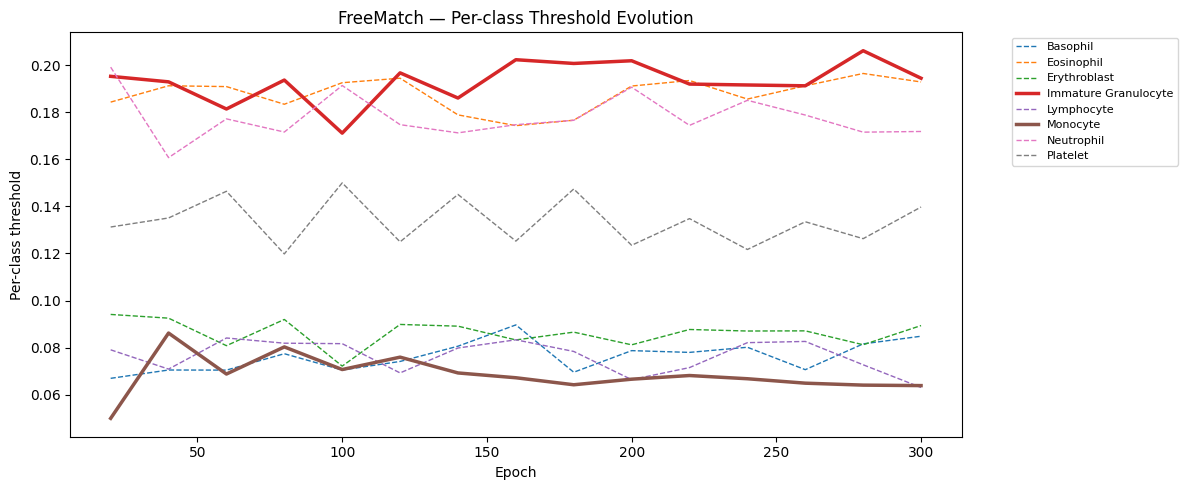

Saved to freematch_thresholds.png


In [75]:
plot_threshold_evolution(free_thresh, CLASS_NAMES)

## HemaMatch + DA

In [76]:
USE_HEMA_AUG = True

In [77]:
# ============================================================
# Dynamic Class Prior Estimation
# ============================================================

# Dynamically estimate the class prior p(y|X) from your labeled training set [D.1]
labeled_labels = []
for _, labels in labeled_loader:
    labeled_labels.extend(labels.squeeze().numpy())

unique_classes, counts = np.unique(labeled_labels, return_counts=True)
prior_counts = np.zeros(8)
for u, c in zip(unique_classes, counts):
    prior_counts[int(u)] = c

# Normalize prior frequencies and move to device [D.1]
class_prior = torch.tensor(prior_counts / prior_counts.sum(), dtype=torch.float32).to(device)
print(f"Estimated Class Prior p(y|X) for 1% split: {class_prior.cpu().numpy()}")

# Select the appropriate dataloader cycle and checkpoint name
if USE_HEMA_AUG:
    active_unlabeled_cycle = hema_unlabeled_cycle  # Hema-Aug loader
    CHECKPOINT_NAME = "hemamatch_full_best.pth"
    run_name = "Full HemaMatch (Hema-Aug + DA) with Adaptive Thresholding"
else:
    active_unlabeled_cycle = unlabeled_cycle       # Standard RandAugment loader
    CHECKPOINT_NAME = "fixmatch_da_best.pth"
    run_name = "Standard FixMatch + DA with Adaptive Thresholding"

Estimated Class Prior p(y|X) for 1% split: [0.08035714 0.1875     0.09821428 0.16071428 0.07142857 0.08035714
 0.1875     0.13392857]


In [78]:
# ============================================================
# Model & Training Setup
# ============================================================

# Freshly re-initialize model for Phase 7 to ensure clean weights [3.1]
model = get_resnet18_backbone(num_classes=8).to(device)

criterion_supervised = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(), 
    lr=0.03, 
    momentum=0.9, 
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

# Initialize the running mean prediction vector p_m(y|U) [D.1, 7.1]
running_mean = None

In [79]:
# Training Loop with Distribution Alignment
# ============================================================

print(f"\n--- Starting Training: {run_name} ---")
best_val_acc = 0.0
start_time = time.time()

# Fresh FreeMatch instance for this condition
free_thresh = FreeMatchThreshold(
num_classes=8, momentum=0.9, device=device)
running_mean = None  # reset DA running mean too

for epoch in range(1, 301):
    model.train()
    
    running_loss_s = 0.0
    running_loss_u = 0.0
    running_mask_ratio = 0.0
    steps_in_epoch = 0
    
    for (labeled_imgs, labels), (weak_unlabeled, strong_unlabeled) in zip(labeled_loader, active_unlabeled_cycle):
        
        labeled_imgs = labeled_imgs.to(device)
        labels = labels.squeeze().long().to(device)
        
        weak_unlabeled = weak_unlabeled.to(device)
        strong_unlabeled = strong_unlabeled.to(device)
        
        # Step 1: Supervised Loss
        logits_labeled = model(labeled_imgs)
        loss_supervised = criterion_supervised(logits_labeled, labels)
        
        # Step 2: Pseudo-Label Generation with Distribution Alignment [D.1, 7.1]
        with torch.no_grad():
            logits_weak = model(weak_unlabeled)
            probs_weak = torch.softmax(logits_weak, dim=1)
            
            # Update running mean p_m(y|U) using EMA momentum of 0.9 [D.1, 7.1]
            if running_mean is None:
                running_mean = probs_weak.mean(dim=0).detach()
            else:
                running_mean = 0.9 * running_mean + 0.1 * probs_weak.mean(dim=0).detach()
                
            # Distribution Alignment scaling: q_tilde = q * (prior / running_mean) [D.1, 7.1]
            probs_aligned = probs_weak * (class_prior / (running_mean + 1e-6))
            probs_aligned = probs_aligned / probs_aligned.sum(dim=1, keepdim=True)  # Re-normalize to sum to 1 [D.1]
            
            # Update FreeMatch thresholds using aligned probs
            free_thresh.update(probs_aligned)
            
            # FreeMatch adaptive mask on aligned probs
            confidence, pseudo_labels = probs_aligned.max(dim=1)
            mask = free_thresh.get_mask(probs_aligned, pseudo_labels)
                        
        # Step 3: Consistency Loss on Strong Unlabeled
        logits_strong = model(strong_unlabeled)
        raw_loss_u = F.cross_entropy(logits_strong, pseudo_labels, reduction='none')
        loss_unsupervised = (raw_loss_u * mask).mean()
        
        # Step 4: Combined Loss with Lambda Ramp-Up
        lambda_u = get_lambda_ramp(epoch, ramp_epochs=20)
        total_loss = loss_supervised + lambda_u * loss_unsupervised
        
        # Gradient Update
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        running_loss_s += loss_supervised.item()
        running_loss_u += loss_unsupervised.item()
        running_mask_ratio += mask.mean().item()
        steps_in_epoch += 1
        
    scheduler.step()
    
    epoch_loss_s = running_loss_s / steps_in_epoch
    epoch_loss_u = running_loss_u / steps_in_epoch
    epoch_mask_ratio = running_mask_ratio / steps_in_epoch
    
    # Evaluate every 10 epochs [5.1]
    if epoch % 10 == 0 or epoch == 1:
        val_acc, val_f1, _, _ = evaluate_model(model, val_loader, device)
        print(f"Epoch {epoch:03d}/{EPOCHS} | Loss S: {epoch_loss_s:.4f} | Loss U: {epoch_loss_u:.4f} | "
              f"Mask Ratio: {epoch_mask_ratio*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
        
        if epoch % 20 == 0:
            free_thresh.log_thresholds(epoch, CLASS_NAMES)
            print(f"  [DA Running Mean]: {running_mean.cpu().numpy().round(4)}")
        
        # Log running_mean distribution convergence check [7.1]
        if epoch % 50 == 0:
            print(f"  [EMA Running Mean p_m(y|U) Convergence Check]:\n  {running_mean.cpu().numpy()}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'val_f1': val_f1,
                'mask_ratio': epoch_mask_ratio,
                'running_mean': running_mean
            }, CHECKPOINT_NAME)
            print(f"  ✔ New best model saved to {CHECKPOINT_NAME} (Val Acc: {val_acc*100:.2f}%)")

training_duration = time.time() - start_time
print(f"\nTraining completed in {training_duration/60:.2f} minutes!")
print(f"Best Validation Accuracy achieved: {best_val_acc*100:.2f}%")



--- Starting Training: Full HemaMatch (Hema-Aug + DA) with Adaptive Thresholding ---
Epoch 001/300 | Loss S: 1.9868 | Loss U: 1.5838 | Mask Ratio: 100.00% | Val Acc: 25.76% | Val F1: 0.1109
  ✔ New best model saved to hemamatch_full_best.pth (Val Acc: 25.76%)
Epoch 010/300 | Loss S: 0.1263 | Loss U: 0.7635 | Mask Ratio: 100.00% | Val Acc: 84.00% | Val F1: 0.8162
  ✔ New best model saved to hemamatch_full_best.pth (Val Acc: 84.00%)
Epoch 020/300 | Loss S: 0.0801 | Loss U: 0.6165 | Mask Ratio: 100.00% | Val Acc: 87.68% | Val F1: 0.8458

[FreeMatch] Epoch 20 — Per-class thresholds (global mean: 0.1250):
  Basophil                    : 0.0753 ←
  Eosinophil                  : 0.1814
  Erythroblast                : 0.0833 ←
  Immature Granulocyte        : 0.1667
  Lymphocyte                  : 0.0723 ←
  Monocyte                    : 0.0919 ←
  Neutrophil                  : 0.1810
  Platelet                    : 0.1481
  [DA Running Mean]: [0.074  0.1804 0.0817 0.1758 0.0707 0.0878 0.1811 

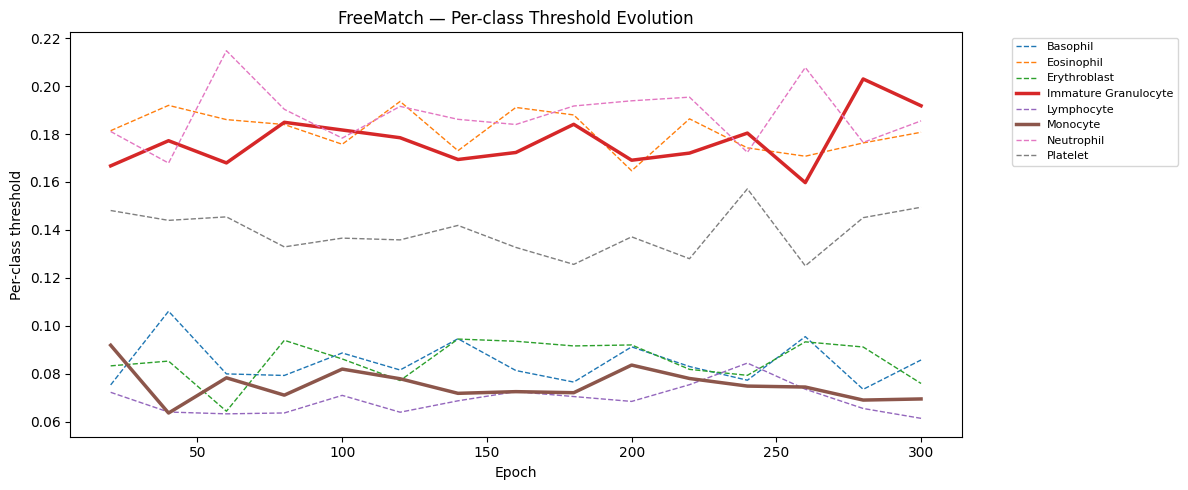

Saved to freematch_thresholds.png


In [80]:
plot_threshold_evolution(free_thresh, CLASS_NAMES)


--- Running Final Evaluation on Test Set: Full HemaMatch (Hema-Aug + DA) with Adaptive Thresholding ---
Loaded best checkpoint from epoch 270 with Val Acc 95.56%

=== Full HemaMatch (Hema-Aug + DA) with Adaptive Thresholding Test Set Performance ===
Overall Test Accuracy : 94.07%
Macro F1-Score        : 0.9335

Detailed Per-Class Performance:
                      precision    recall  f1-score   support

            Basophil       0.86      1.00      0.93       244
          Eosinophil       1.00      1.00      1.00       624
        Erythroblast       0.98      0.90      0.94       311
Immature Granulocyte       0.83      0.89      0.86       579
          Lymphocyte       0.93      0.99      0.96       243
            Monocyte       0.93      0.74      0.83       284
          Neutrophil       0.97      0.96      0.97       666
            Platelet       1.00      1.00      1.00       470

            accuracy                           0.94      3421
           macro avg       0.94 

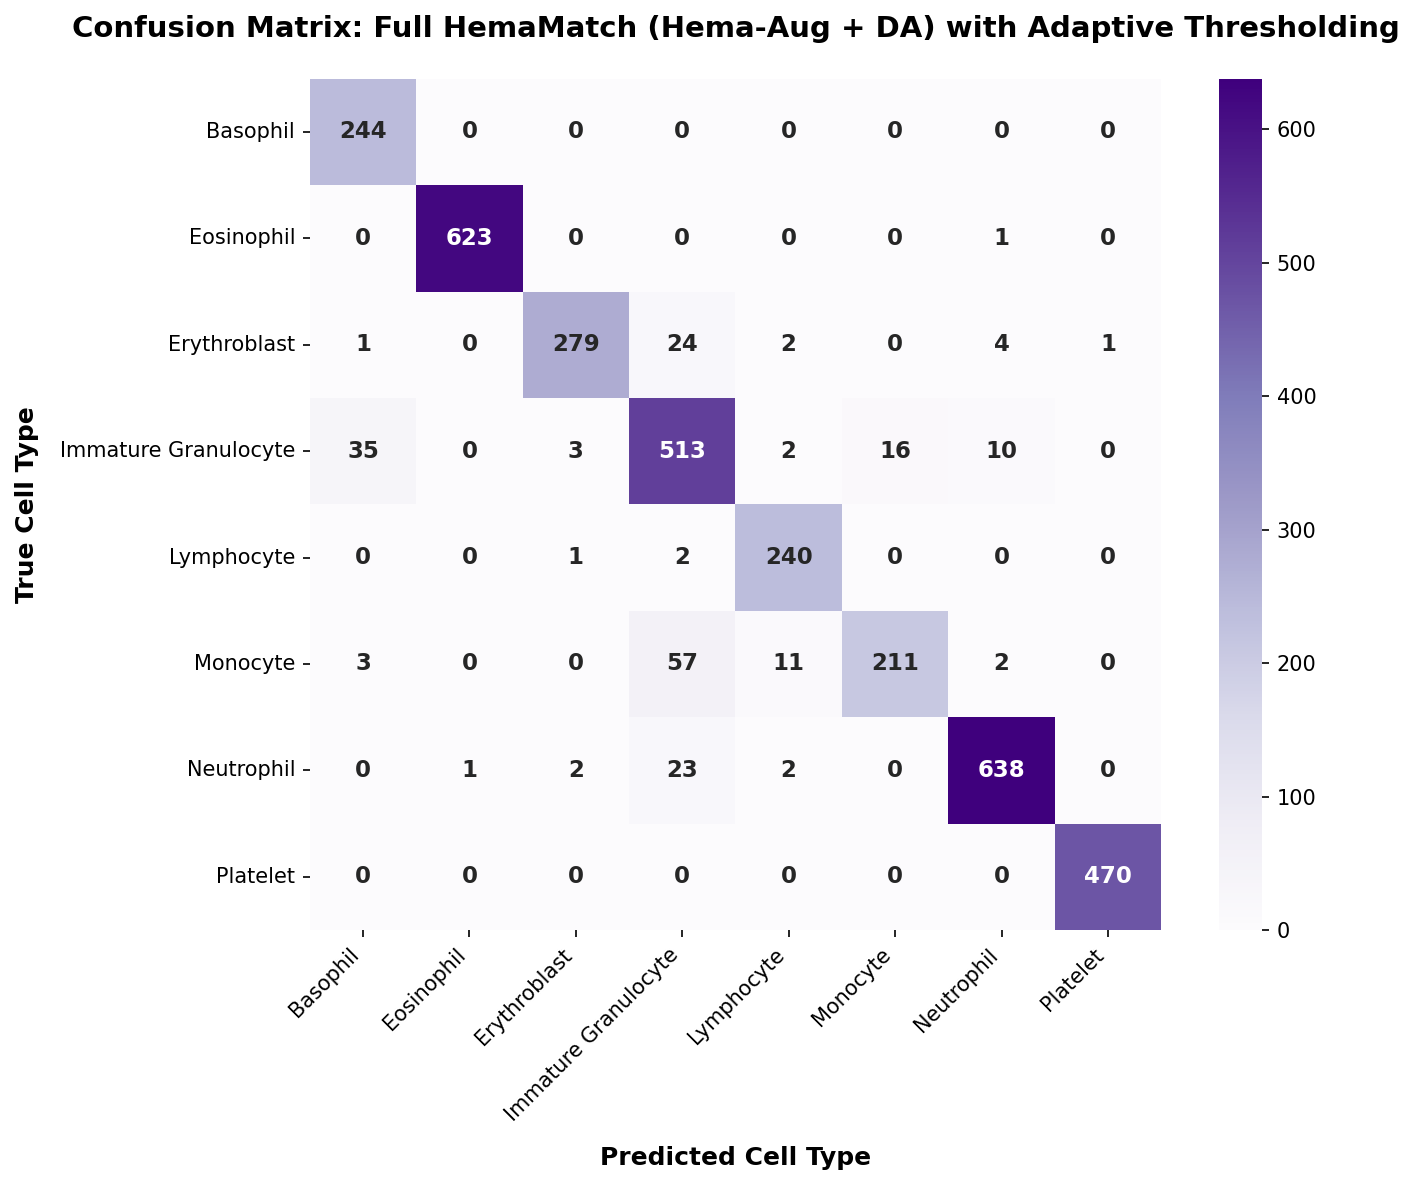

✔ Updated existing metrics for 'Full HemaMatch (Hema-Aug + DA) with Adaptive Thresholding' in hema_results_summary.csv.

=== PERSISTENT METHODOLOGY LEADERBOARD ===


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,92.66%,0.9291,0.9137,0.9186,0.9576,0.9944,0.9103,0.8305,0.9585,0.7434,0.9595,0.9947
1,Hema-Aug with Adaptive Thresholding,95.06%,0.9480,0.9427,0.9433,0.9699,0.9984,0.9154,0.8998,0.9254,0.8712,0.9681,0.9979
2,Standard FixMatch + DA,92.34%,0.9255,0.9107,0.9144,0.9675,0.9889,0.9181,0.8320,0.9490,0.7140,0.9543,0.9915
3,Full HemaMatch (Hema-Aug + DA) with Adaptive Thresholding,94.07%,0.9379,0.9338,0.9335,0.9260,0.9984,0.9362,0.8564,0.9600,0.8258,0.9659,0.9989


,Method,Accuracy,Macro Precision,Macro Recall,Macro F1,Basophil F1,Eosinophil F1,Erythroblast F1,Immature Granulocyte F1,Lymphocyte F1,Monocyte F1,Neutrophil F1,Platelet F1
0,Standard FixMatch with Adaptive Thresholding,0.926630,0.929120,0.913671,0.918608,0.957576,0.994368,0.910256,0.830549,0.958506,0.743434,0.959511,0.994664
1,Hema-Aug with Adaptive Thresholding,0.950599,0.948023,0.942711,0.943264,0.969940,0.998397,0.915371,0.899751,0.925430,0.871212,0.968134,0.997872
2,Standard FixMatch + DA,0.923414,0.925494,0.910687,0.914418,0.967480,0.988906,0.918089,0.832013,0.949020,0.713996,0.954299,0.991543
3,Full HemaMatch (Hema-Aug + DA) with Adaptive T...,0.940661,0.937948,0.933760,0.933471,0.925996,0.998397,0.936242,0.856427,0.960000,0.825832,0.965935,0.998937


In [82]:
# ============================================================
# Final Test Evaluation
# ============================================================

print(f"\n--- Running Final Evaluation on Test Set: {run_name} ---")

# Load best checkpoint
checkpoint = torch.load(CHECKPOINT_NAME)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} with Val Acc {checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
test_acc, test_f1, true_labels, pred_labels = evaluate_model(model, test_loader, device)

print(f"\n=== {run_name} Test Set Performance ===")
print(f"Overall Test Accuracy : {test_acc*100:.2f}%")
print(f"Macro F1-Score        : {test_f1:.4f}")
print("======================================================")

print("\nDetailed Per-Class Performance:")
print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))

# Define an automatic, descriptive filename for saving
save_filename = f"{run_name.lower().replace(' ', '_').replace('+', 'and')}_confusion_matrix.png"

# Generate the beautiful colorful plot
print("\nGenerating Confusion Matrix Plot...")
plot_colorful_confusion_matrix(
    true_labels=true_labels, 
    pred_labels=pred_labels, 
    class_names=CLASS_NAMES, 
    run_name=run_name,
    save_path=save_filename
)

log_run_results(
    run_name=run_name,
    true_labels=true_labels,
    pred_labels=pred_labels,
    test_acc=test_acc,
    test_f1=test_f1
)